# Beyond Accuracy: A Basel- and IFRS-Aligned Evaluation of Credit Default Risk Models

**Dataset:** UCI Credit Card Default (30,000 borrowers)  
**Models:** Logistic Regression (WoE Scorecard), Random Forest, XGBoost, LightGBM, MLP  
**Evaluation:** AUC, Gini, KS, Brier, PSI, Hosmer-Lemeshow, SHAP, Stress Testing, Monte Carlo, IFRS9 ECL


## 1. Install Dependencies & Import Libraries

In [1]:
!pip install scorecardpy imbalanced-learn xgboost lightgbm shap statsmodels seaborn -q

import pandas as pd
import numpy as np
import json, os, warnings, pickle, joblib
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ks_2samp, chi2

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, brier_score_loss,
    precision_recall_curve, classification_report,
    confusion_matrix, average_precision_score
)
from sklearn.calibration import calibration_curve

import xgboost as xgb
import lightgbm as lgb
import shap
import scorecardpy as sc
from statsmodels.stats.outliers_influence import variance_inflation_factor

os.makedirs('results', exist_ok=True)
os.makedirs('plots',   exist_ok=True)

print("All libraries imported successfully.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
All libraries imported successfully.


### Helper: Isotonic Calibrator (sklearn 1.8 compatible)

In [2]:
class IsotonicCalibrator:
    def __init__(self, base_model):
        self.base_model = base_model
        self.iso = IsotonicRegression(out_of_bounds='clip')

    def fit(self, X_val, y_val):
        raw = self.base_model.predict_proba(X_val)[:, 1]
        self.iso.fit(raw, np.array(y_val))
        return self

    def predict_proba(self, X):
        raw = self.base_model.predict_proba(X)[:, 1]
        return self.iso.predict(raw)


## 2. Data Loading & Cleaning

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/credit_risk_model_project/UCI_Credit_Card.csv'
except ImportError:
    DATA_PATH = 'UCI_Credit_Card.csv'

df = pd.read_csv(DATA_PATH)
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

if 'ID' in df.columns:
    df.drop(columns=['ID'], inplace=True)

df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE']  = df['MARRIAGE'].replace(0, 3)

pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
for col in pay_cols:
    df[col] = df[col].replace([-2, -1], 0)

print(f"Shape         : {df.shape}")
print(f"Missing vals  : {df.isnull().sum().sum()}")
print(f"Default rate  : {df['default'].mean()*100:.1f}%")
print(f"Class counts  : {df['default'].value_counts().to_dict()}")
df.head()


Mounted at /content/drive
Shape         : (30000, 24)
Missing vals  : 0
Default rate  : 22.1%
Class counts  : {0: 23364, 1: 6636}


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,0,0,0,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,0,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,0,0,0,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 3. Exploratory Data Analysis

### 3.1 Default Rate by Demographics

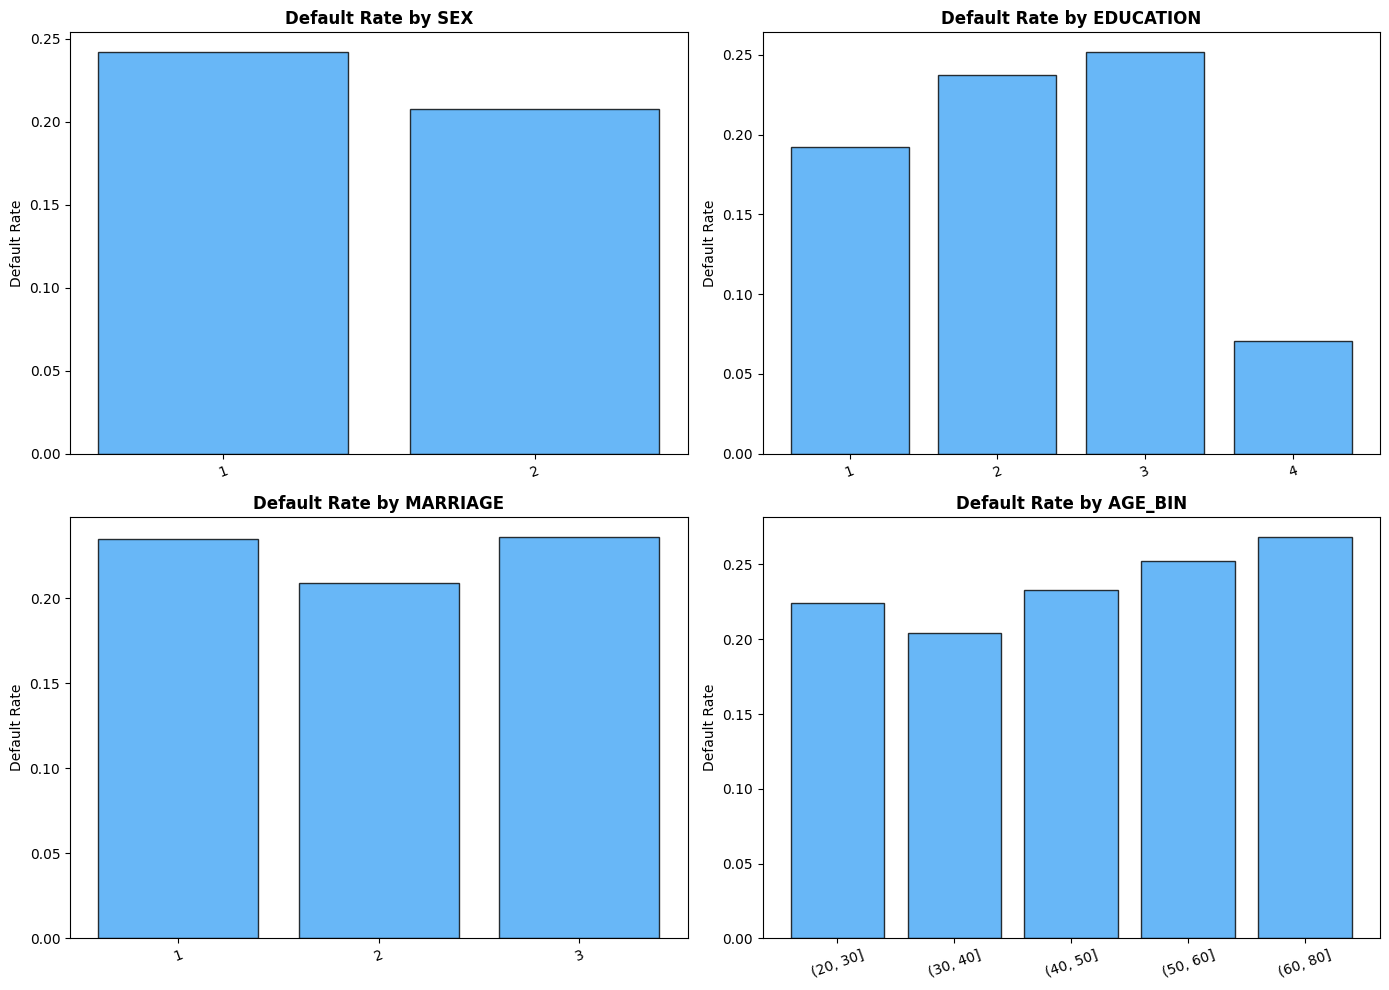

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df['AGE_BIN'] = pd.cut(df['AGE'], bins=[20,30,40,50,60,80])
for ax, col in zip(axes.flatten(), ['SEX','EDUCATION','MARRIAGE','AGE_BIN']):
    grp = df.groupby(col)['default'].mean().reset_index()
    ax.bar(grp[col].astype(str), grp['default'], alpha=0.8, edgecolor='black', color='#42A5F5')
    ax.set_title(f'Default Rate by {col}', fontweight='bold')
    ax.set_ylabel('Default Rate')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('plots/eda_demographics.png', dpi=100)
plt.show()
df.drop(columns=['AGE_BIN'], errors='ignore', inplace=True)


### 3.2 Correlation Heatmap

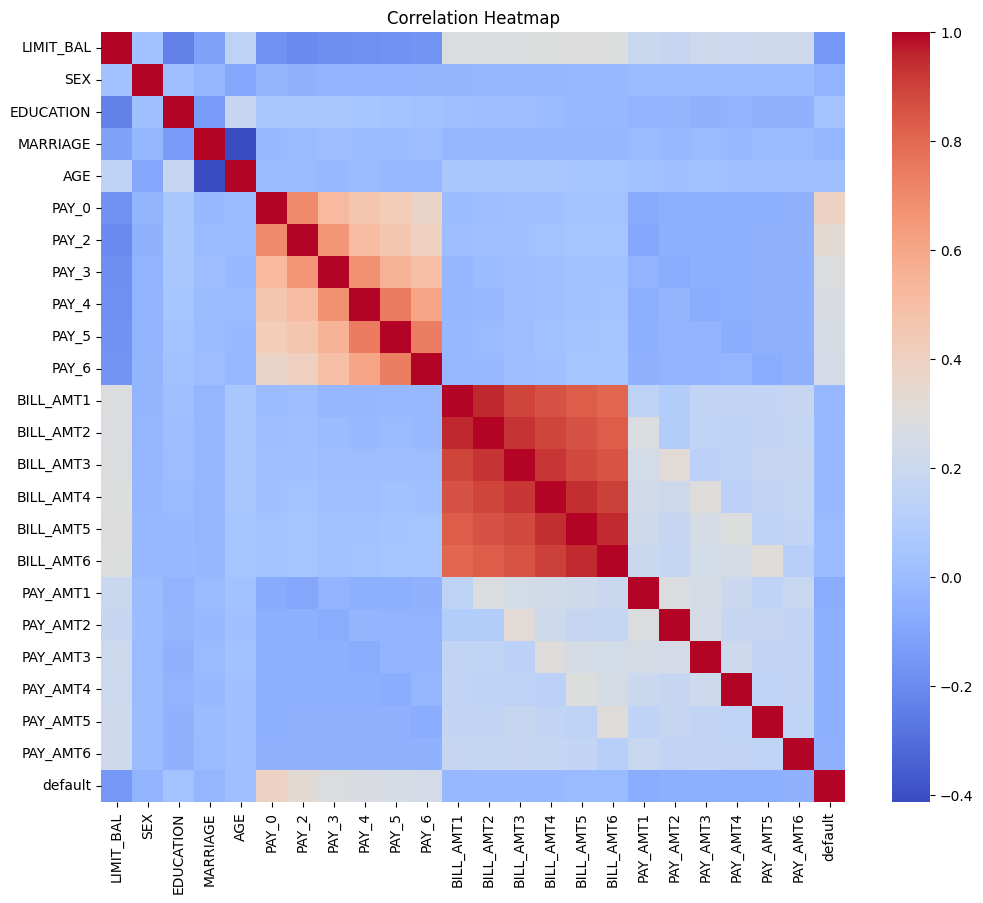

In [5]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.savefig('plots/eda_correlation.png', dpi=100)
plt.show()


### 3.3 Statistical Significance Tests

In [6]:
print("Chi-Square tests (categorical features vs default):")
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    ct = pd.crosstab(df[col], df['default'])
    _, p_val, _, _ = chi2_contingency(ct)
    sig = '*Significant*' if p_val < 0.05 else 'Not significant'
    print(f"  {col:<12} p={p_val:.4f}  {sig}")

print("\nDescriptive Statistics:")
df.describe()


Chi-Square tests (categorical features vs default):
  SEX          p=0.0000  *Significant*
  EDUCATION    p=0.0000  *Significant*
  MARRIAGE     p=0.0000  *Significant*

Descriptive Statistics:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.842267,1.557267,35.485500,0.356767,0.320033,0.304067,0.258767,0.22150,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.744494,0.521405,9.217904,0.760594,0.801727,0.790589,0.761113,0.71772,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,1.000000,1.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,4.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.00000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## 4. Train / Validation / Test Split (70/15/15)

In [7]:
X = df.drop(columns=['default'])
y = df['default']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train : {X_train.shape}  default rate={y_train.mean()*100:.1f}%")
print(f"Val   : {X_val.shape}  default rate={y_val.mean()*100:.1f}%")
print(f"Test  : {X_test.shape}  default rate={y_test.mean()*100:.1f}%")


Train : (21000, 23)  default rate=22.1%
Val   : (4500, 23)  default rate=22.1%
Test  : (4500, 23)  default rate=22.1%


## 5. Feature Engineering

In [8]:
def create_features(data):
    d = data.copy()
    pc = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
    d['AVG_DELAY']    = d[pc].mean(axis=1)
    d['MAX_DELAY']    = d[pc].max(axis=1)
    d['NUM_LATE_PAY'] = (d[pc] > 0).sum(axis=1)
    for i in range(1, 7):
        bill = d[f'BILL_AMT{i}'].clip(lower=0).fillna(0).astype(float)
        pay  = d[f'PAY_AMT{i}'].clip(lower=0).fillna(0).astype(float)
        d[f'PAY_RATIO{i}'] = pay / (bill + 1e-6)
    bc = [f'BILL_AMT{i}' for i in range(1, 7)]
    d['AVG_UTIL']      = d[bc].mean(axis=1) / (d['LIMIT_BAL'] + 1e-6)
    d['UTIL_RATIO']    = d['BILL_AMT1'] / (d['LIMIT_BAL'] + 1e-6)
    d['AVG_PAY_RATIO'] = d[[f'PAY_RATIO{i}' for i in range(1,7)]].mean(axis=1)
    for i in range(1, 4):
        d[f'BILL_CHANGE{i}'] = d[f'BILL_AMT{i}'] - d[f'BILL_AMT{i+1}']
        d[f'PAY_CHANGE{i}']  = d[f'PAY_AMT{i}']  - d[f'PAY_AMT{i+1}']
    return d

selected_features = [
    'AVG_DELAY','MAX_DELAY','NUM_LATE_PAY',
    'AVG_PAY_RATIO','UTIL_RATIO','AVG_UTIL',
    'PAY_RATIO1','PAY_RATIO2','PAY_RATIO3',
    'BILL_CHANGE1','BILL_CHANGE2','BILL_CHANGE3',
    'PAY_CHANGE1','PAY_CHANGE2','PAY_CHANGE3'
]

X_train = create_features(X_train)
X_val   = create_features(X_val)
X_test  = create_features(X_test)

clip_bounds = {}
for col in selected_features:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99)
    clip_bounds[col] = (lo, hi)
    for ds in [X_train, X_val, X_test]:
        ds[col] = ds[col].clip(lo, hi)

X_train = X_train[selected_features]
X_val   = X_val[selected_features]
X_test  = X_test[selected_features]

print(f"Features: {selected_features}")
print(f"NaN count: {X_train.isna().sum().sum()}")


Features: ['AVG_DELAY', 'MAX_DELAY', 'NUM_LATE_PAY', 'AVG_PAY_RATIO', 'UTIL_RATIO', 'AVG_UTIL', 'PAY_RATIO1', 'PAY_RATIO2', 'PAY_RATIO3', 'BILL_CHANGE1', 'BILL_CHANGE2', 'BILL_CHANGE3', 'PAY_CHANGE1', 'PAY_CHANGE2', 'PAY_CHANGE3']
NaN count: 0


## 6. Class Imbalance — Basel-Compliant Approach

SMOTE **not used** — it creates synthetic borrowers which distorts the empirical PD distribution, violating Basel IRB data integrity requirements and IFRS9 Point-in-Time calibration.

Instead: `class_weight='balanced'` (LR/RF), `scale_pos_weight` (XGBoost/LightGBM), Youden's J threshold.

Training class distribution: {0: 16355, 1: 4645}
Default rate preserved at  : 22.1% (real portfolio)
scale_pos_weight (XGBoost/LightGBM): 3.52


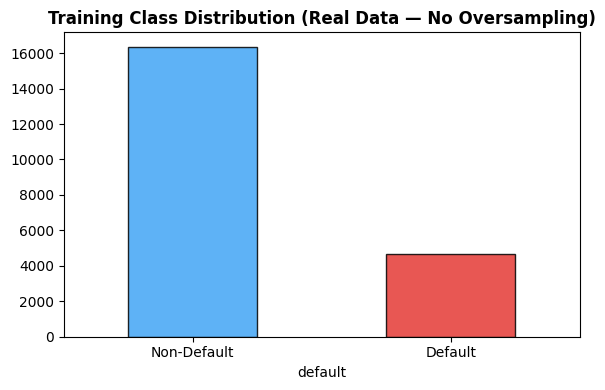

In [9]:

print(f"Training class distribution: {y_train.value_counts().to_dict()}")
print(f"Default rate preserved at  : {y_train.mean()*100:.1f}% (real portfolio)")


scale_pw = float((y_train==0).sum()) / float((y_train==1).sum())
print(f"scale_pos_weight (XGBoost/LightGBM): {scale_pw:.2f}")

X_train_sm, y_train_sm = X_train, y_train

fig, ax = plt.subplots(figsize=(6, 4))
y_train.value_counts().plot(kind='bar', ax=ax, color=['#42A5F5','#E53935'],
                             edgecolor='black', alpha=0.85)
ax.set_title('Training Class Distribution (Real Data — No Oversampling)', fontweight='bold')
ax.set_xticklabels(['Non-Default','Default'], rotation=0)
plt.tight_layout()
plt.show()


## 7. WoE / IV Binning & Feature Selection

Weight of Evidence + Information Value — the standard Basel IRB scorecard methodology.

In [10]:
def make_woe_df(X, y):
    d = X.copy()
    d['default'] = y.values if hasattr(y, 'values') else np.array(y)
    return d.replace([np.inf, -np.inf], np.nan).fillna(0)

train_woe_raw = make_woe_df(X_train, y_train)
val_woe_raw   = make_woe_df(X_val,   y_val)
test_woe_raw  = make_woe_df(X_test,  y_test)

bins      = sc.woebin(train_woe_raw, y='default', bin_num_limit=5, ignore_datetime_cols=False)
train_woe = sc.woebin_ply(train_woe_raw, bins, print_step=0)
val_woe   = sc.woebin_ply(val_woe_raw,   bins, print_step=0)
test_woe  = sc.woebin_ply(test_woe_raw,  bins, print_step=0)

iv_summary = sc.iv(train_woe_raw, y='default')
iv_summary = iv_summary.sort_values('info_value', ascending=False).reset_index(drop=True)
iv_summary.to_csv('results/iv_summary.csv', index=False)

print("IV Summary (IV >= 0.1 selected):")
display(iv_summary)


[INFO] creating woe binning ...
Binning on 21000 rows and 16 columns in 00:00:31
[INFO] converting into woe values ...
[INFO] converting into woe values ...
[INFO] converting into woe values ...
IV Summary (IV >= 0.1 selected):


,variable,info_value
0,AVG_DELAY,0.927666
1,NUM_LATE_PAY,0.892472
2,MAX_DELAY,0.807260
3,PAY_CHANGE1,0.363339
4,PAY_CHANGE2,0.361588
5,PAY_CHANGE3,0.351093
6,BILL_CHANGE1,0.309849
7,BILL_CHANGE2,0.307065
8,BILL_CHANGE3,0.299605
9,PAY_RATIO3,0.081432


### 7.1 VIF — Multicollinearity + DELAY_RISK Composite

In [11]:
selected_iv = iv_summary[iv_summary['info_value'] >= 0.1]['variable'].tolist()
woe_cols    = [c + '_woe' for c in selected_iv if c + '_woe' in train_woe.columns]

X_train_woe = train_woe[woe_cols].copy()
X_val_woe   = val_woe[woe_cols].copy()
X_test_woe  = test_woe[woe_cols].copy()
y_train_woe = train_woe['default']
y_val_woe   = val_woe['default']
y_test_woe  = test_woe['default']

def calculate_vif(X):
    vif = pd.DataFrame()
    vif['Feature'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif.sort_values('VIF', ascending=False)

print("VIF before composite:")
display(calculate_vif(X_train_woe))

def build_delay_risk_woe(df_w):
    df_w = df_w.copy()
    delay_cols = [c for c in ['AVG_DELAY_woe','NUM_LATE_PAY_woe','MAX_DELAY_woe'] if c in df_w.columns]
    df_w['DELAY_RISK_woe'] = (
        0.5 * df_w.get('MAX_DELAY_woe',    pd.Series(0, index=df_w.index)) +
        0.3 * df_w.get('AVG_DELAY_woe',    pd.Series(0, index=df_w.index)) +
        0.2 * df_w.get('NUM_LATE_PAY_woe', pd.Series(0, index=df_w.index))
    )
    for c in delay_cols:
        if c in df_w.columns:
            df_w.drop(columns=[c], inplace=True)
    return df_w

X_train_woe = build_delay_risk_woe(X_train_woe)
X_val_woe   = build_delay_risk_woe(X_val_woe)
X_test_woe  = build_delay_risk_woe(X_test_woe)

print("\nVIF after DELAY_RISK composite:")
display(calculate_vif(X_train_woe))

X_train_woe_sm, y_train_woe_sm = X_train_woe, y_train_woe
print(f"\nFinal WoE features: {list(X_train_woe.columns)}")


VIF before composite:


,Feature,VIF
0,AVG_DELAY_woe,38.766304
1,NUM_LATE_PAY_woe,31.595485
2,MAX_DELAY_woe,10.885812
7,BILL_CHANGE2_woe,1.464843
4,PAY_CHANGE2_woe,1.445192
8,BILL_CHANGE3_woe,1.398156
3,PAY_CHANGE1_woe,1.355171
6,BILL_CHANGE1_woe,1.262844
5,PAY_CHANGE3_woe,1.238618



VIF after DELAY_RISK composite:


,Feature,VIF
4,BILL_CHANGE2_woe,1.463878
1,PAY_CHANGE2_woe,1.444649
5,BILL_CHANGE3_woe,1.396247
0,PAY_CHANGE1_woe,1.354596
3,BILL_CHANGE1_woe,1.260482
2,PAY_CHANGE3_woe,1.238480
6,DELAY_RISK_woe,1.070241



Final WoE features: ['PAY_CHANGE1_woe', 'PAY_CHANGE2_woe', 'PAY_CHANGE3_woe', 'BILL_CHANGE1_woe', 'BILL_CHANGE2_woe', 'BILL_CHANGE3_woe', 'DELAY_RISK_woe']


## 8. Evaluation Helper Functions

In [12]:
def hosmer_lemeshow(y_true, y_prob, g=10):
    df_hl = pd.DataFrame({'y': np.array(y_true), 'p': np.array(y_prob)})
    df_hl['decile'] = pd.qcut(df_hl['p'], q=g, duplicates='drop')
    grp = df_hl.groupby('decile').agg(
        obs_events=('y','sum'), n=('y','count'), mean_pred=('p','mean')
    ).reset_index()
    grp = grp[grp['n'] > 0]
    grp['pred_events'] = grp['mean_pred'] * grp['n']
    grp['pred_non']    = grp['n'] - grp['pred_events']
    grp['obs_non']     = grp['n'] - grp['obs_events']
    hl = (((grp['obs_events'] - grp['pred_events'])**2 / (grp['pred_events']+1e-9)) +
          ((grp['obs_non']    - grp['pred_non']   )**2 / (grp['pred_non']+1e-9))).sum()
    return hl, 1 - chi2.cdf(hl, df=max(g-2,1)), grp

def calculate_psi(expected, actual, buckets=10):
    bp = np.linspace(0, 1, buckets + 1)
    ep = np.histogram(expected, bins=bp)[0] / len(expected)
    ap = np.histogram(actual,   bins=bp)[0] / len(actual)
    ep = np.where(ep == 0, 1e-8, ep)
    ap = np.where(ap == 0, 1e-8, ap)
    return ((ep - ap) * np.log(ep / ap)).sum()

def ks_stat(y_true, y_prob):
    p_def = y_prob[np.array(y_true) == 1]
    p_non = y_prob[np.array(y_true) == 0]
    return ks_2samp(p_def, p_non)[0]

def youden_threshold(y_true, y_prob):
    fpr, tpr, thresh = roc_curve(y_true, y_prob)
    return thresh[np.argmax(tpr - fpr)]

def full_eval(name, y_true, y_prob, y_prob_train):
    y_true = np.array(y_true); y_prob = np.array(y_prob)
    thresh = youden_threshold(y_true, y_prob)
    y_pred = (y_prob >= thresh).astype(int)

    auc    = roc_auc_score(y_true, y_prob)
    gini   = 2*auc - 1
    ks     = ks_stat(y_true, y_prob)
    brier  = brier_score_loss(y_true, y_prob)
    brier_base = y_true.mean() * (1 - y_true.mean())
    bss    = 1 - brier/brier_base
    pr_auc = average_precision_score(y_true, y_prob)
    _, hl_p, _ = hosmer_lemeshow(y_true, y_prob)
    psi    = calculate_psi(y_prob_train, y_prob)
    cm     = confusion_matrix(y_true, y_pred)
    recall_1    = cm[1,1] / (cm[1,:].sum() + 1e-9)
    precision_1 = cm[1,1] / (cm[:,1].sum() + 1e-9)
    f1_1        = 2*recall_1*precision_1 / (recall_1+precision_1+1e-9)

    return {
        'Model':name, 'AUC':round(auc,4), 'Gini':round(gini,4), 'KS':round(ks,4),
        'PR-AUC':round(pr_auc,4), 'Brier':round(brier,4), 'BSS':round(bss,4),
        'HL p-val':round(hl_p,4), 'PSI':round(psi,4),
        'Recall(1)':round(recall_1,4), 'Precision(1)':round(precision_1,4),
        'F1(1)':round(f1_1,4), 'Threshold':round(thresh,4),
        'Basel_AUC': 'PASS' if auc>0.70 else 'FAIL',
        'Basel_Gini':'PASS' if gini>0.30 else 'FAIL',
        'Basel_KS':  'PASS' if ks>0.20  else 'FAIL',
        'Basel_PSI': 'PASS' if psi<0.10 else ('WARN' if psi<0.25 else 'FAIL'),
        'IFRS9_HL':  'PASS' if hl_p>0.05 else ('WARN' if hl_p>0.01 else 'FAIL'),
        'IFRS9_Brier':'PASS' if brier<brier_base else 'FAIL',
    }

print("Helper functions defined.")


Helper functions defined.


## 9. Model Training

All models use:
- **SMOTE** oversampled training data
- **Isotonic calibration** on validation set
- **Youden's J threshold** (cost-sensitive, bank-appropriate)

### 9.1 Logistic Regression (WoE Scorecard)

In [13]:
lr_base = LogisticRegression(max_iter=2000, solver='lbfgs',
                             class_weight='balanced', random_state=42)
lr_base.fit(X_train_woe_sm, y_train_woe_sm)

lr_cal = IsotonicCalibrator(lr_base)
lr_cal.fit(X_val_woe, y_val_woe)

y_prob_lr_train = lr_cal.predict_proba(X_train_woe)
y_prob_lr       = lr_cal.predict_proba(X_test_woe)

res_lr = full_eval('LR (WoE+Scorecard)', y_test_woe, y_prob_lr, y_prob_lr_train)
print(f"AUC={res_lr['AUC']}  Gini={res_lr['Gini']}  KS={res_lr['KS']}  Recall(1)={res_lr['Recall(1)']}")
print(classification_report(np.array(y_test_woe),
      (y_prob_lr >= res_lr['Threshold']).astype(int),
      target_names=['Non-Default','Default']))


AUC=0.7392  Gini=0.4785  KS=0.394  Recall(1)=0.6074
              precision    recall  f1-score   support

 Non-Default       0.86      0.84      0.85      3504
     Default       0.48      0.53      0.50       996

    accuracy                           0.77      4500
   macro avg       0.67      0.68      0.67      4500
weighted avg       0.78      0.77      0.77      4500



### 9.2 Random Forest

In [14]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            random_state=42, n_jobs=-1, max_depth=10, min_samples_leaf=20)
rf.fit(X_train_sm, y_train_sm)

rf_cal = IsotonicCalibrator(rf)
rf_cal.fit(X_val, y_val)

y_prob_rf_train = rf_cal.predict_proba(X_train)
y_prob_rf       = rf_cal.predict_proba(X_test)

res_rf = full_eval('Random Forest', y_test, y_prob_rf, y_prob_rf_train)
print(f"AUC={res_rf['AUC']}  Gini={res_rf['Gini']}  KS={res_rf['KS']}  Recall(1)={res_rf['Recall(1)']}")
print(classification_report(np.array(y_test),
      (y_prob_rf >= res_rf['Threshold']).astype(int),
      target_names=['Non-Default','Default']))


AUC=0.7664  Gini=0.5328  KS=0.4068  Recall(1)=0.6014
              precision    recall  f1-score   support

 Non-Default       0.88      0.81      0.84      3504
     Default       0.47      0.60      0.53       996

    accuracy                           0.76      4500
   macro avg       0.67      0.70      0.68      4500
weighted avg       0.79      0.76      0.77      4500



### 9.3 XGBoost

In [15]:
scale_pw  = float((y_train_sm==0).sum()) / float((y_train_sm==1).sum())
xgb_model = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    scale_pos_weight=scale_pw, subsample=0.8, colsample_bytree=0.8,
    eval_metric='auc', random_state=42, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train_sm, y_train_sm, eval_set=[(X_val, y_val)], verbose=False)

xgb_cal = IsotonicCalibrator(xgb_model)
xgb_cal.fit(X_val, y_val)

y_prob_xgb_train = xgb_cal.predict_proba(X_train)
y_prob_xgb       = xgb_cal.predict_proba(X_test)

res_xgb = full_eval('XGBoost', y_test, y_prob_xgb, y_prob_xgb_train)
print(f"AUC={res_xgb['AUC']}  Gini={res_xgb['Gini']}  KS={res_xgb['KS']}  Recall(1)={res_xgb['Recall(1)']}")
print(classification_report(np.array(y_test),
      (y_prob_xgb >= res_xgb['Threshold']).astype(int),
      target_names=['Non-Default','Default']))


AUC=0.758  Gini=0.5159  KS=0.4063  Recall(1)=0.6526
              precision    recall  f1-score   support

 Non-Default       0.88      0.75      0.81      3504
     Default       0.43      0.65      0.52       996

    accuracy                           0.73      4500
   macro avg       0.66      0.70      0.67      4500
weighted avg       0.78      0.73      0.75      4500



### 9.4 LightGBM

In [16]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    scale_pos_weight=scale_pw, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train_sm, y_train_sm,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

lgb_cal = IsotonicCalibrator(lgb_model)
lgb_cal.fit(X_val, y_val)

y_prob_lgb_train = lgb_cal.predict_proba(X_train)
y_prob_lgb       = lgb_cal.predict_proba(X_test)

res_lgb = full_eval('LightGBM', y_test, y_prob_lgb, y_prob_lgb_train)
print(f"AUC={res_lgb['AUC']}  Gini={res_lgb['Gini']}  KS={res_lgb['KS']}  Recall(1)={res_lgb['Recall(1)']}")
print(classification_report(np.array(y_test),
      (y_prob_lgb >= res_lgb['Threshold']).astype(int),
      target_names=['Non-Default','Default']))


AUC=0.7618  Gini=0.5236  KS=0.4041  Recall(1)=0.6606
              precision    recall  f1-score   support

 Non-Default       0.89      0.74      0.81      3504
     Default       0.42      0.66      0.52       996

    accuracy                           0.73      4500
   macro avg       0.65      0.70      0.66      4500
weighted avg       0.78      0.73      0.74      4500



### 9.5 MLP (Neural Network)

In [17]:
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_tst_sc = scaler.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu',
                    solver='adam', max_iter=300, early_stopping=True,
                    validation_fraction=0.1, random_state=42,
                    alpha=0.001, batch_size=256)
mlp.fit(X_tr_sc, y_train)

mlp_cal = IsotonicCalibrator(mlp)
mlp_cal.fit(X_val_sc, y_val)

y_prob_mlp_train = mlp_cal.predict_proba(scaler.transform(X_train))
y_prob_mlp       = mlp_cal.predict_proba(X_tst_sc)

res_mlp = full_eval('MLP', y_test, y_prob_mlp, y_prob_mlp_train)
print(f"AUC={res_mlp['AUC']}  Gini={res_mlp['Gini']}  KS={res_mlp['KS']}  Recall(1)={res_mlp['Recall(1)']}")
print(classification_report(np.array(y_test),
      (y_prob_mlp >= res_mlp['Threshold']).astype(int),
      target_names=['Non-Default','Default']))


AUC=0.7505  Gini=0.5011  KS=0.3956  Recall(1)=0.5894
              precision    recall  f1-score   support

 Non-Default       0.87      0.81      0.84      3504
     Default       0.46      0.59      0.52       996

    accuracy                           0.76      4500
   macro avg       0.67      0.70      0.68      4500
weighted avg       0.78      0.76      0.77      4500



## 10. Model Comparison — Basel & IFRS9 Evaluation Table

In [18]:
results_list = [res_lr, res_rf, res_xgb, res_lgb, res_mlp]
results_df   = pd.DataFrame(results_list)
results_df.to_csv('results/model_comparison.csv', index=False)

display(results_df[[
    'Model','AUC','Gini','KS','PR-AUC','Brier','BSS',
    'HL p-val','PSI','Recall(1)','F1(1)',
    'Basel_AUC','Basel_Gini','Basel_KS','Basel_PSI','IFRS9_HL','IFRS9_Brier'
]])


,Model,AUC,Gini,KS,PR-AUC,Brier,BSS,HL p-val,PSI,Recall(1),F1(1),Basel_AUC,Basel_Gini,Basel_KS,Basel_PSI,IFRS9_HL,IFRS9_Brier
0,LR (WoE+Scorecard),0.7392,0.4785,0.3940,0.4559,0.1462,0.1519,0.0837,0.0005,0.6074,0.5151,PASS,PASS,PASS,PASS,PASS,PASS
1,Random Forest,0.7664,0.5328,0.4068,0.4901,0.1414,0.1796,0.1198,0.0036,0.6014,0.5261,PASS,PASS,PASS,PASS,PASS,PASS
2,XGBoost,0.7580,0.5159,0.4063,0.4925,0.1424,0.1735,0.3185,0.0074,0.6526,0.5181,PASS,PASS,PASS,PASS,PASS,PASS
3,LightGBM,0.7618,0.5236,0.4041,0.4908,0.1416,0.1782,0.1432,0.0003,0.6606,0.5155,PASS,PASS,PASS,PASS,PASS,PASS
4,MLP,0.7505,0.5011,0.3956,0.4806,0.1436,0.1669,0.0539,0.0021,0.5894,0.5190,PASS,PASS,PASS,PASS,PASS,PASS


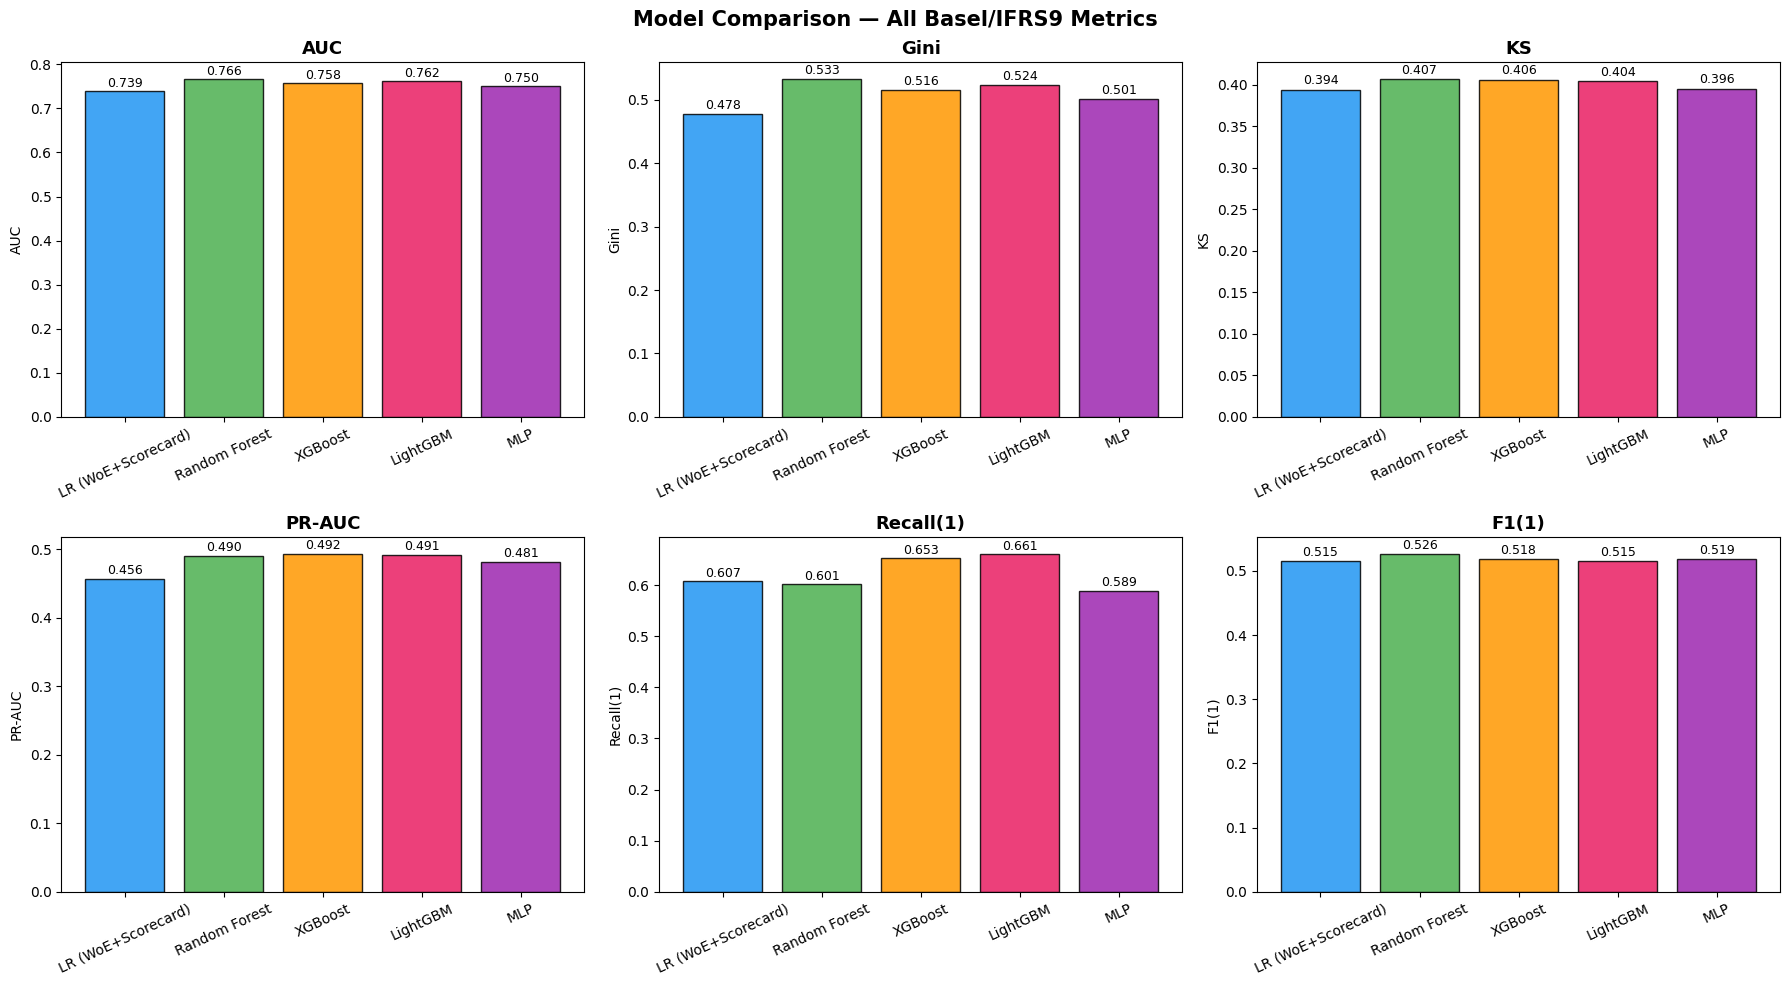

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_  = ['AUC','Gini','KS','PR-AUC','Recall(1)','F1(1)']
colors_   = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']
for ax, metric in zip(axes.flatten(), metrics_):
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors_, alpha=0.85, edgecolor='black')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric); ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Model Comparison — All Basel/IFRS9 Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=120)
plt.show()


## 11. ROC Curves & Calibration — All Models

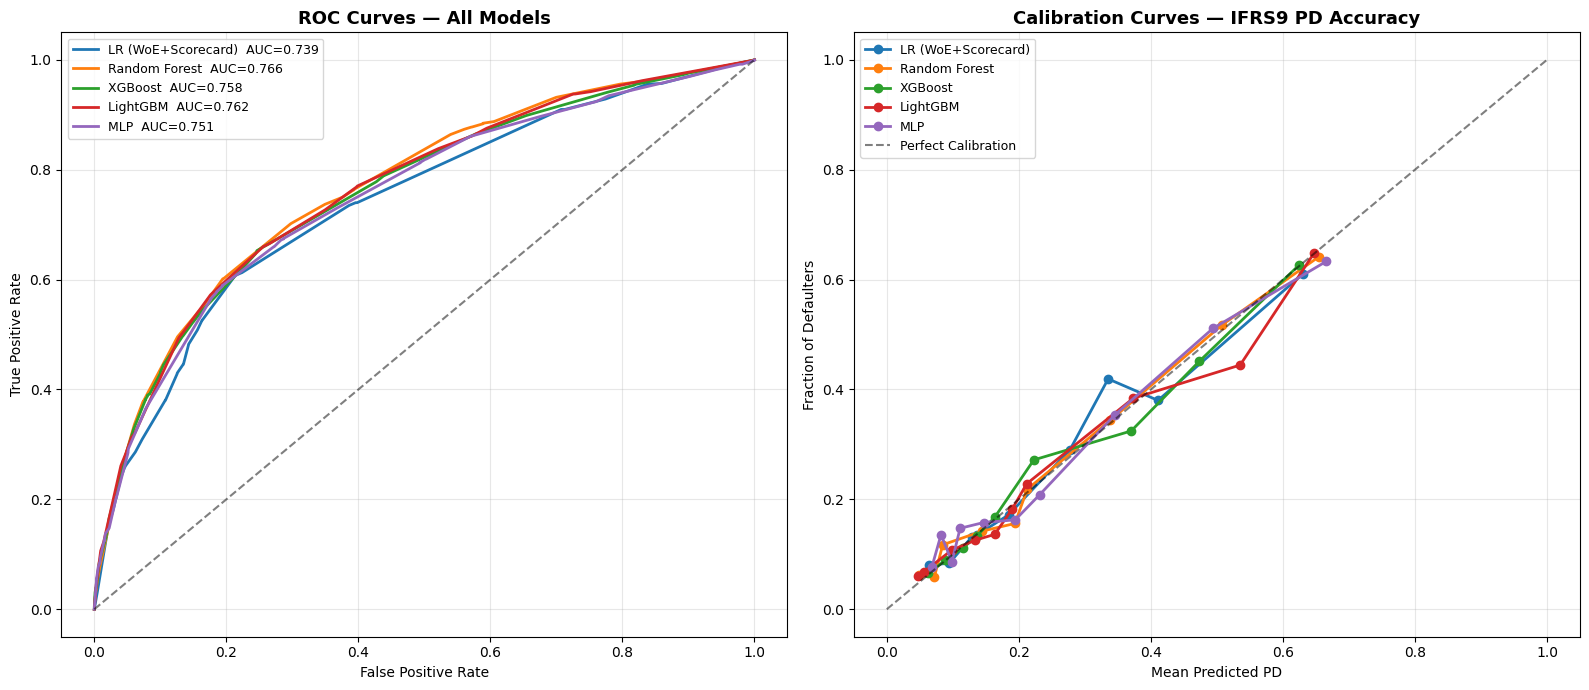

In [20]:
models_eval = [
    ('LR (WoE+Scorecard)', y_test_woe, y_prob_lr),
    ('Random Forest',      y_test,     y_prob_rf),
    ('XGBoost',            y_test,     y_prob_xgb),
    ('LightGBM',           y_test,     y_prob_lgb),
    ('MLP',                y_test,     y_prob_mlp),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for name, yt, yp in models_eval:
    fpr, tpr, _ = roc_curve(yt, yp)
    auc = roc_auc_score(yt, yp)
    axes[0].plot(fpr, tpr, label=f'{name}  AUC={auc:.3f}', linewidth=2)
axes[0].plot([0,1],[0,1],'k--',alpha=0.5)
axes[0].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

for name, yt, yp in models_eval:
    fp, mp = calibration_curve(yt, yp, n_bins=10, strategy='quantile')
    axes[1].plot(mp, fp, marker='o', label=name, linewidth=2)
axes[1].plot([0,1],[0,1],'k--',alpha=0.5,label='Perfect Calibration')
axes[1].set_title('Calibration Curves — IFRS9 PD Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Predicted PD'); axes[1].set_ylabel('Fraction of Defaulters')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/roc_calibration.png', dpi=120)
plt.show()


## 12. SHAP Explainability (Basel Model Risk Governance)

### 12.1 XGBoost SHAP — Feature Impact

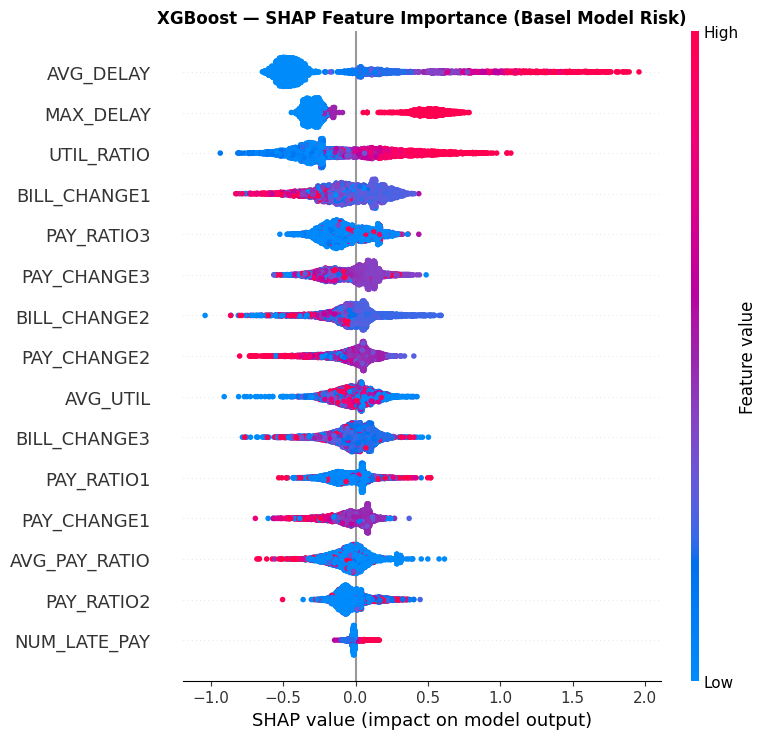

In [21]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_vals_xgb = explainer_xgb.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_xgb, X_test, show=False)
plt.title('XGBoost — SHAP Feature Importance (Basel Model Risk)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/shap_xgb_summary.png', dpi=120, bbox_inches='tight')
plt.show()


### 12.2 XGBoost SHAP — Mean |SHAP| Bar

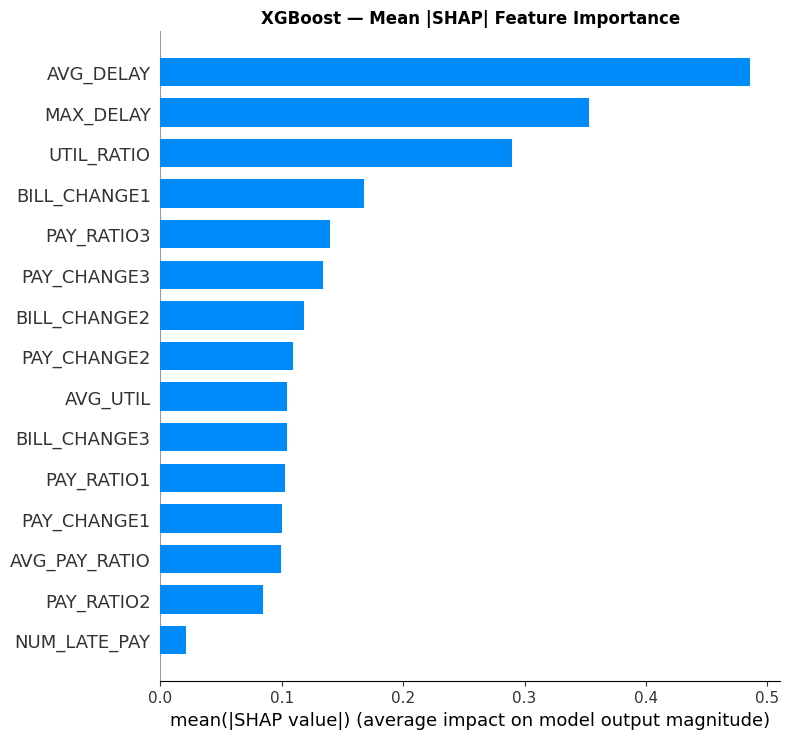

In [22]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_xgb, X_test, plot_type='bar', show=False)
plt.title('XGBoost — Mean |SHAP| Feature Importance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/shap_xgb_bar.png', dpi=120, bbox_inches='tight')
plt.show()


### 12.3 Random Forest SHAP (TreeExplainer)

<Figure size 1000x700 with 0 Axes>

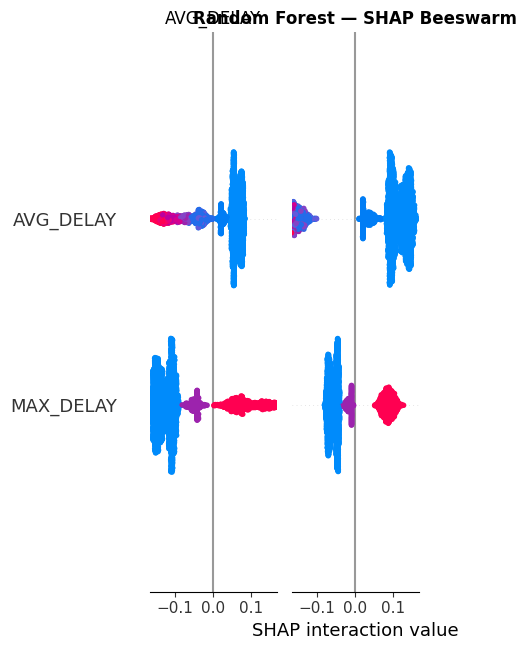

<Figure size 1000x700 with 0 Axes>

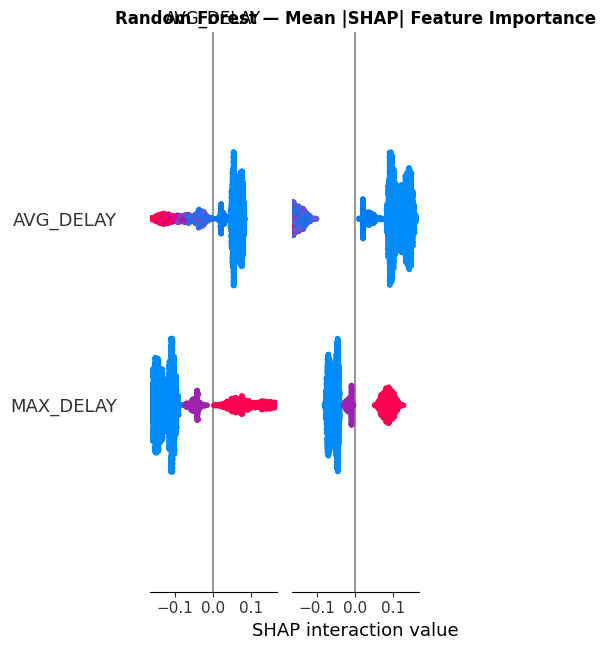

In [23]:
explainer_rf  = shap.TreeExplainer(rf)
shap_vals_rf  = explainer_rf.shap_values(X_test)
sv_rf = shap_vals_rf[1] if isinstance(shap_vals_rf, list) else shap_vals_rf

plt.figure(figsize=(10, 7))
shap.summary_plot(sv_rf, X_test, show=False)
plt.title('Random Forest — SHAP Beeswarm', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/shap_rf_summary.png', dpi=120, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(sv_rf, X_test, plot_type='bar', show=False)
plt.title('Random Forest — Mean |SHAP| Feature Importance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/shap_rf_bar.png', dpi=120, bbox_inches='tight')
plt.show()

### 12.4 SHAP Dependence Plots — Top 3 Features

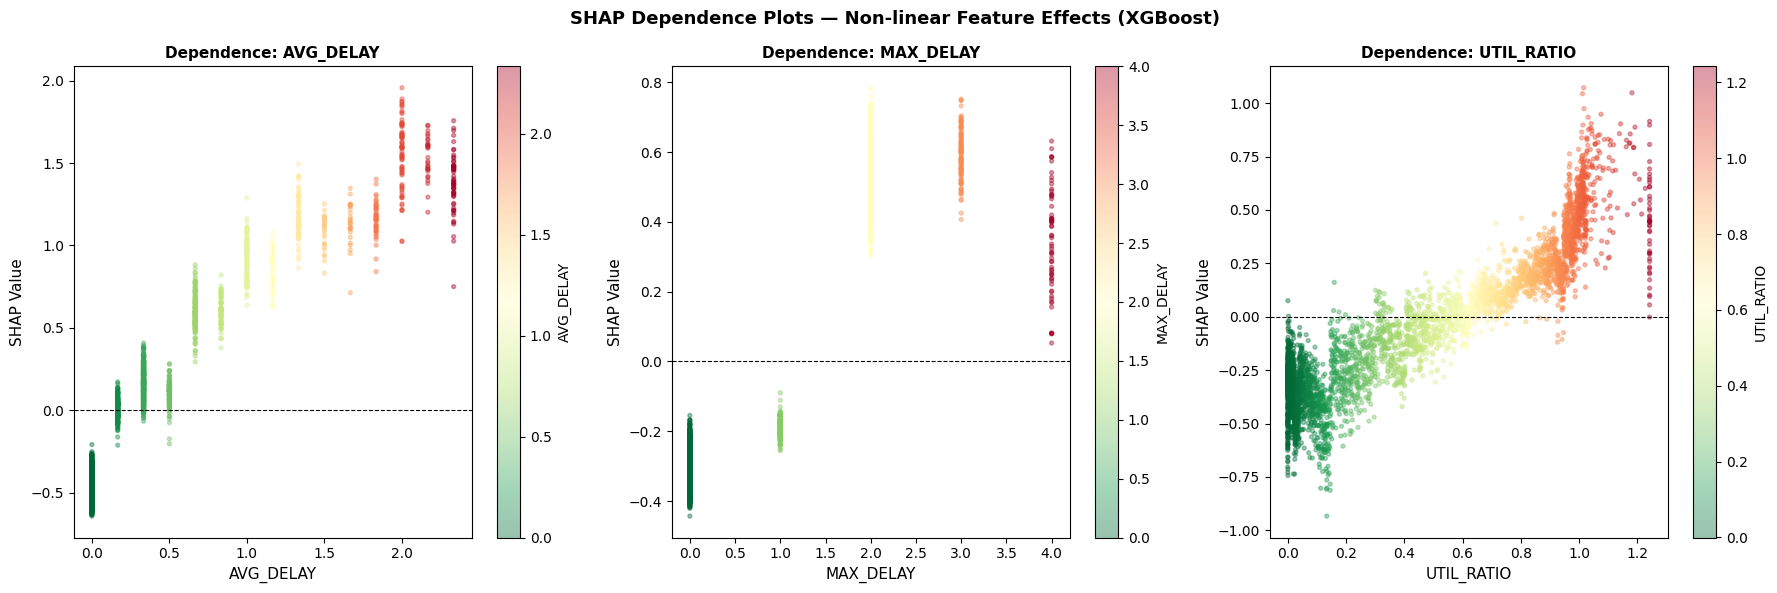

In [24]:
mean_abs_shap = np.abs(shap_vals_xgb).mean(axis=0)
top3_idx      = np.argsort(mean_abs_shap)[::-1][:3]
top3_features = [X_test.columns[i] for i in top3_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, feat in zip(axes, top3_features):
    feat_idx  = list(X_test.columns).index(feat)
    shap_col  = shap_vals_xgb[:, feat_idx]
    feat_vals = X_test[feat].values
    sc2 = ax.scatter(feat_vals, shap_col, c=feat_vals, cmap='RdYlGn_r', alpha=0.4, s=8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feat, fontsize=11); ax.set_ylabel('SHAP Value', fontsize=11)
    ax.set_title(f'Dependence: {feat}', fontweight='bold', fontsize=11)
    plt.colorbar(sc2, ax=ax, label=feat)
plt.suptitle('SHAP Dependence Plots — Non-linear Feature Effects (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/shap_dependence.png', dpi=120, bbox_inches='tight')
plt.show()

### 12.5 SHAP Force Plots — Individual Borrower Explainability

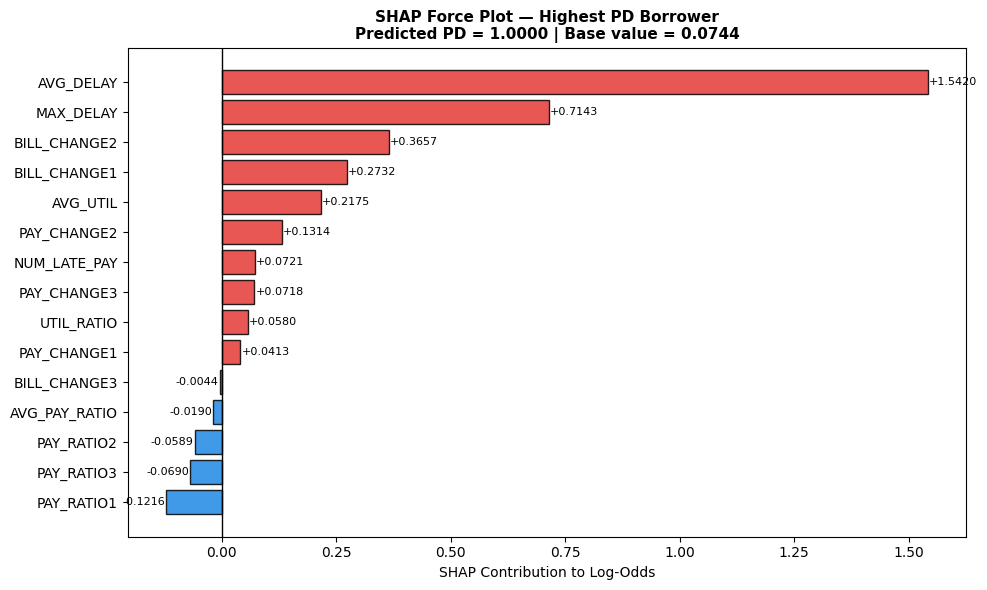

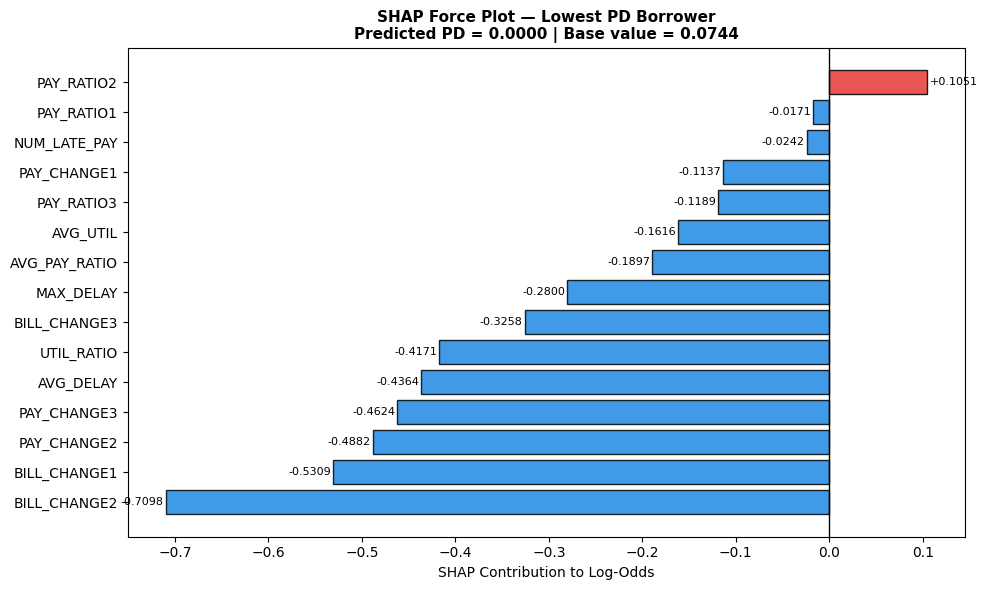

In [25]:
X_test_reset = X_test.reset_index(drop=True)
high_pd_idx  = int(np.argmax(y_prob_xgb))
low_pd_idx   = int(np.argmin(y_prob_xgb))

for label, idx in [('highest_pd', high_pd_idx), ('lowest_pd', low_pd_idx)]:
    exp_val   = explainer_xgb.expected_value
    sv_single = shap_vals_xgb[idx]
    contrib   = pd.Series(sv_single, index=X_test.columns).sort_values()
    colors_f  = ['#E53935' if v > 0 else '#1E88E5' for v in contrib]
    fig, ax   = plt.subplots(figsize=(10, 6))
    bars = ax.barh(contrib.index, contrib.values, color=colors_f, alpha=0.85, edgecolor='black')
    ax.axvline(0, color='black', linewidth=1)
    for bar, val in zip(bars, contrib.values):
        ax.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
                f'{val:+.4f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
    pd_val = y_prob_xgb[idx]
    ax.set_title(
        f'SHAP Force Plot — {"Highest" if label=="highest_pd" else "Lowest"} PD Borrower\n'
        f'Predicted PD = {pd_val:.4f} | Base value = {exp_val:.4f}',
        fontsize=11, fontweight='bold')
    ax.set_xlabel('SHAP Contribution to Log-Odds')
    plt.tight_layout()
    plt.savefig(f'plots/shap_force_{label}.png', dpi=120, bbox_inches='tight')
    plt.show()

<Figure size 1000x700 with 0 Axes>

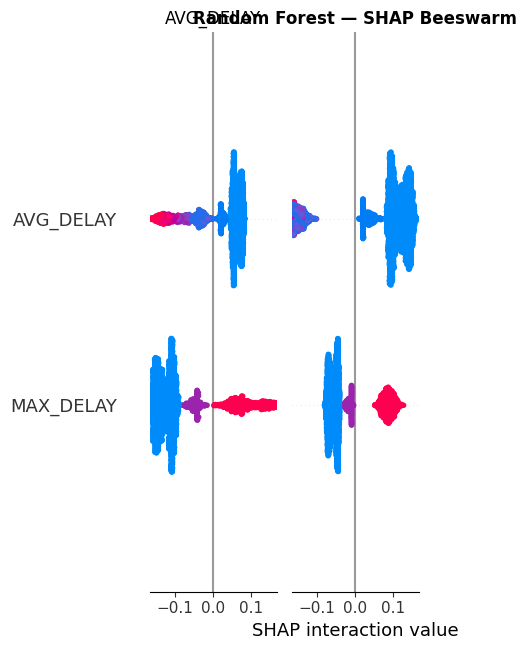

<Figure size 1000x700 with 0 Axes>

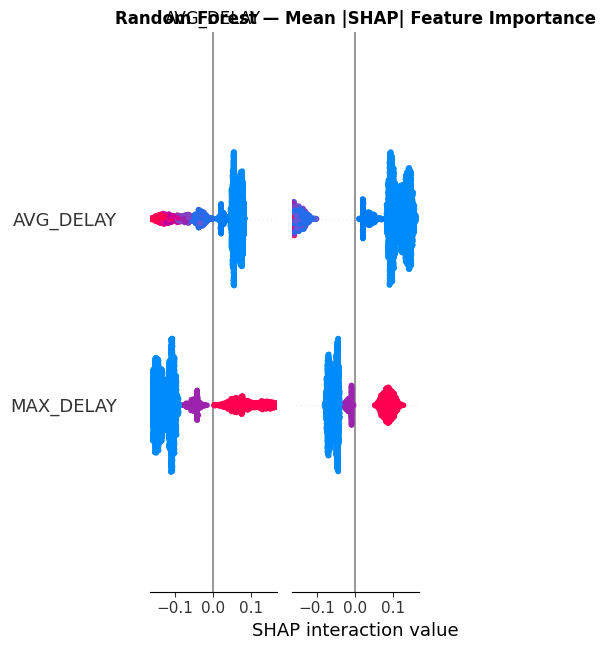

In [26]:
explainer_rf  = shap.TreeExplainer(rf)
shap_vals_rf  = explainer_rf.shap_values(X_test)
sv_rf = shap_vals_rf[1] if isinstance(shap_vals_rf, list) else shap_vals_rf

plt.figure(figsize=(10, 7))
shap.summary_plot(sv_rf, X_test, show=False)
plt.title('Random Forest — SHAP Beeswarm', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/shap_rf_summary.png', dpi=120, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(sv_rf, X_test, plot_type='bar', show=False)
plt.title('Random Forest — Mean |SHAP| Feature Importance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/shap_rf_bar.png', dpi=120, bbox_inches='tight')
plt.show()

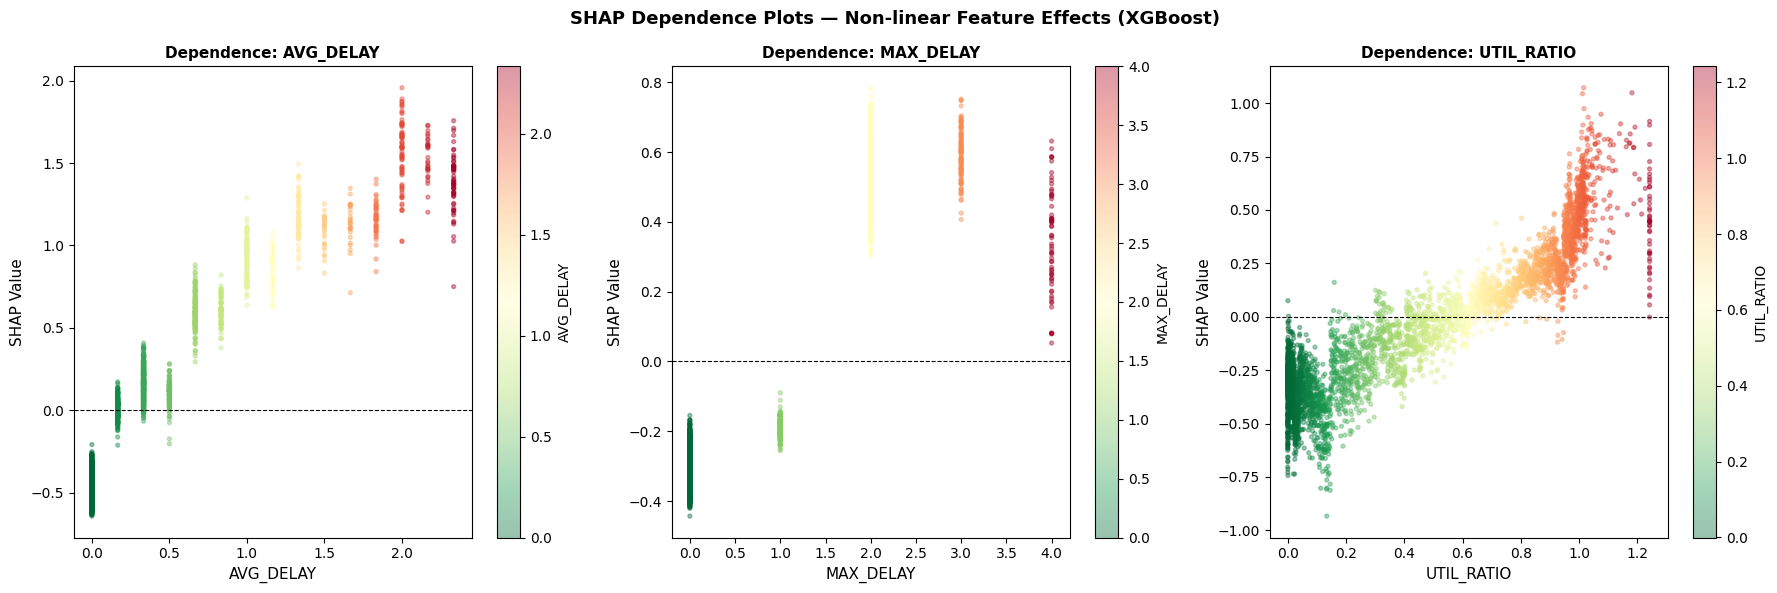

In [27]:
mean_abs_shap = np.abs(shap_vals_xgb).mean(axis=0)
top3_idx      = np.argsort(mean_abs_shap)[::-1][:3]
top3_features = [X_test.columns[i] for i in top3_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, feat in zip(axes, top3_features):
    feat_idx  = list(X_test.columns).index(feat)
    shap_col  = shap_vals_xgb[:, feat_idx]
    feat_vals = X_test[feat].values
    sc2 = ax.scatter(feat_vals, shap_col, c=feat_vals, cmap='RdYlGn_r', alpha=0.4, s=8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(feat, fontsize=11); ax.set_ylabel('SHAP Value', fontsize=11)
    ax.set_title(f'Dependence: {feat}', fontweight='bold', fontsize=11)
    plt.colorbar(sc2, ax=ax, label=feat)
plt.suptitle('SHAP Dependence Plots — Non-linear Feature Effects (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/shap_dependence.png', dpi=120, bbox_inches='tight')
plt.show()

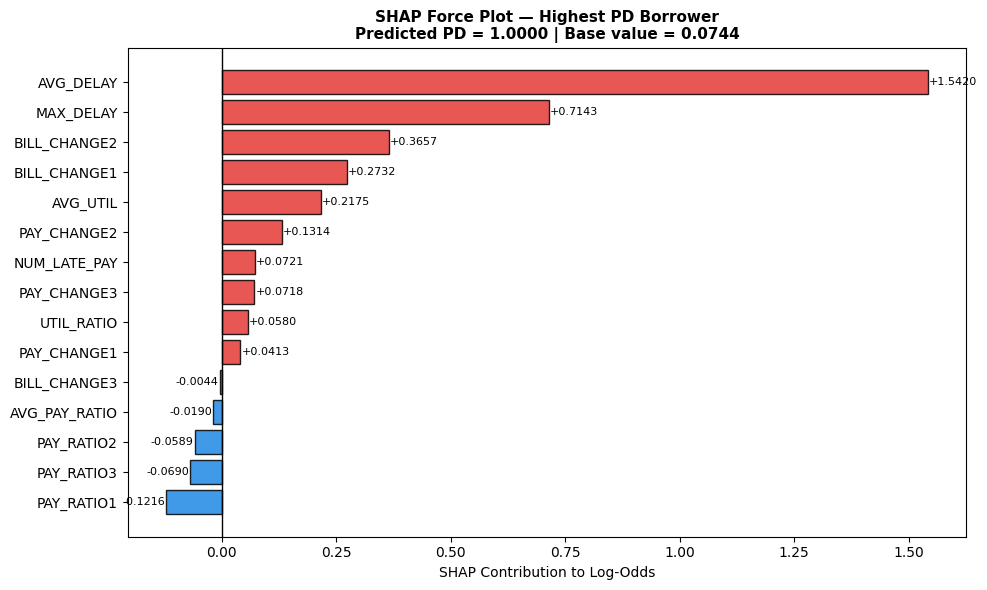

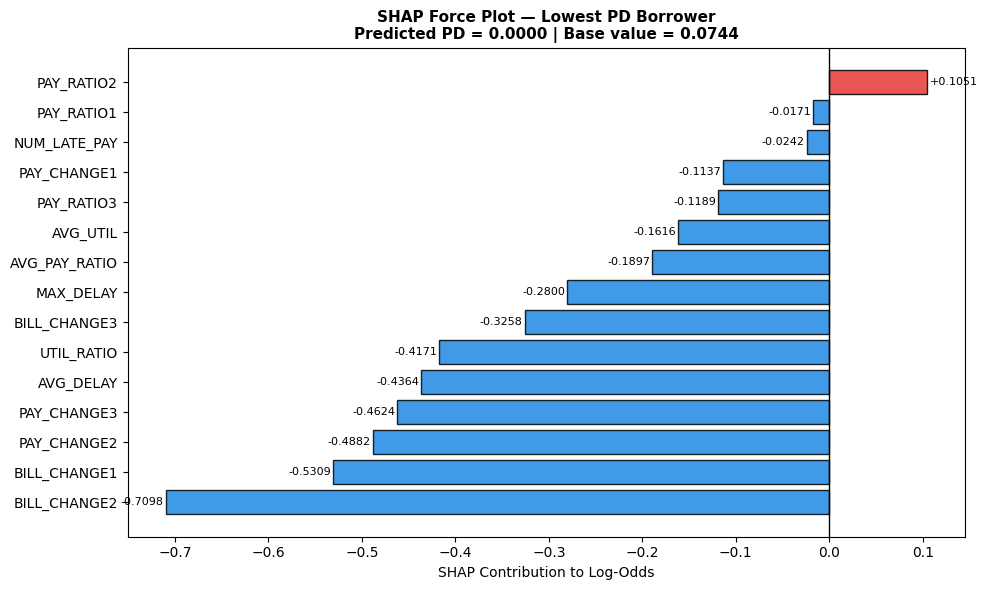

In [28]:
X_test_reset = X_test.reset_index(drop=True)
high_pd_idx  = int(np.argmax(y_prob_xgb))
low_pd_idx   = int(np.argmin(y_prob_xgb))

for label, idx in [('highest_pd', high_pd_idx), ('lowest_pd', low_pd_idx)]:
    exp_val   = explainer_xgb.expected_value
    sv_single = shap_vals_xgb[idx]
    contrib   = pd.Series(sv_single, index=X_test.columns).sort_values()
    colors_f  = ['#E53935' if v > 0 else '#1E88E5' for v in contrib]
    fig, ax   = plt.subplots(figsize=(10, 6))
    bars = ax.barh(contrib.index, contrib.values, color=colors_f, alpha=0.85, edgecolor='black')
    ax.axvline(0, color='black', linewidth=1)
    for bar, val in zip(bars, contrib.values):
        ax.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
                f'{val:+.4f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
    pd_val = y_prob_xgb[idx]
    ax.set_title(
        f'SHAP Force Plot — {"Highest" if label=="highest_pd" else "Lowest"} PD Borrower\n'
        f'Predicted PD = {pd_val:.4f} | Base value = {exp_val:.4f}',
        fontsize=11, fontweight='bold')
    ax.set_xlabel('SHAP Contribution to Log-Odds')
    plt.tight_layout()
    plt.savefig(f'plots/shap_force_{label}.png', dpi=120, bbox_inches='tight')
    plt.show()

### 12.3 Logistic Regression — Coefficients & Odds Ratios

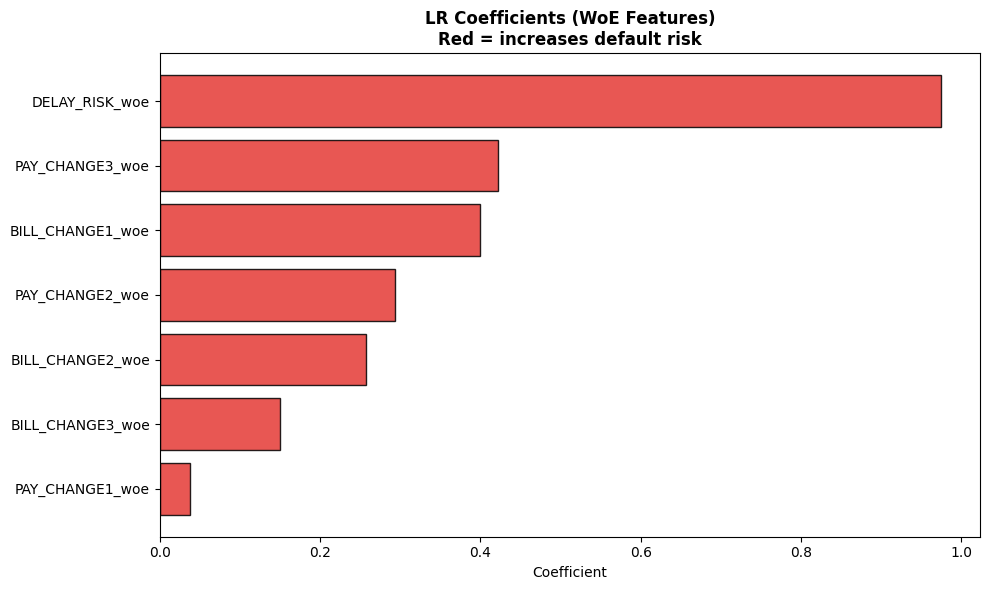

,Feature,Coefficient,OddsRatio
0,PAY_CHANGE1_woe,0.037754,1.038476
5,BILL_CHANGE3_woe,0.150588,1.162517
4,BILL_CHANGE2_woe,0.256830,1.292825
1,PAY_CHANGE2_woe,0.293030,1.340483
3,BILL_CHANGE1_woe,0.400173,1.492082
2,PAY_CHANGE3_woe,0.422512,1.525790
6,DELAY_RISK_woe,0.974427,2.649649


In [29]:
coef_df = pd.DataFrame({
    'Feature':     X_train_woe.columns,
    'Coefficient': lr_base.coef_[0],
    'OddsRatio':   np.exp(lr_base.coef_[0])
}).sort_values('Coefficient')

coef_df.to_csv('results/lr_odds_ratios.csv', index=False)

plt.figure(figsize=(10, 6))
c_colors = ['#E53935' if c > 0 else '#1E88E5' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=c_colors, alpha=0.85, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1.2, linestyle='--')
plt.title('LR Coefficients (WoE Features)\nRed = increases default risk', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient'); plt.tight_layout()
plt.savefig('plots/lr_coefficients.png', dpi=120)
plt.show()

display(coef_df)


## 13. PSI — Model Stability (Basel Validation)

In [30]:
psi_results = []
for name, yp_tr, yp_te in [
    ('LR (WoE+Scorecard)', y_prob_lr_train,  y_prob_lr),
    ('Random Forest',      y_prob_rf_train,  y_prob_rf),
    ('XGBoost',            y_prob_xgb_train, y_prob_xgb),
    ('LightGBM',           y_prob_lgb_train, y_prob_lgb),
    ('MLP',                y_prob_mlp_train, y_prob_mlp),
]:
    psi    = calculate_psi(yp_tr, yp_te)
    status = 'Stable' if psi<0.1 else ('Minor Shift' if psi<0.25 else 'Rebuild Required')
    psi_results.append({'Model':name, 'PSI':round(psi,4), 'Status':status})

psi_df = pd.DataFrame(psi_results)
psi_df.to_csv('results/psi_stability.csv', index=False)
display(psi_df)


,Model,PSI,Status
0,LR (WoE+Scorecard),0.0005,Stable
1,Random Forest,0.0036,Stable
2,XGBoost,0.0074,Stable
3,LightGBM,0.0003,Stable
4,MLP,0.0021,Stable


## 13b. Extended Backtesting — Basel III IRB & IFRS9

Three additional validation tests required by Basel III IRB model validation (SR 11-7) and IFRS9 PiT calibration guidance:

| Test | Framework | Purpose |
|---|---|---|
| **Binomial Test** | IFRS9 | Formal check: predicted DR = actual DR |
| **Traffic Light Test** | Basel III IRB | Exception counting — green/yellow/red zones |
| **Decile Calibration** | Basel III / IFRS9 | Mean PD vs actual DR across risk bands |


In [31]:
from scipy import stats as sp_stats

y_true_bt  = y_test_woe.values
y_pred_bt  = y_prob_lr
n_obs      = len(y_true_bt)
n_defaults = y_true_bt.sum()
actual_dr  = y_true_bt.mean()
pred_dr    = y_pred_bt.mean()

print(f"  Observations : {n_obs}")
print(f"  Actual DR    : {actual_dr:.4f}")
print(f"  Predicted DR : {pred_dr:.4f}")

binom_result = sp_stats.binomtest(k=int(n_defaults), n=n_obs, p=pred_dr, alternative='two-sided')
binom_p    = binom_result.pvalue
binom_pass = 'PASS' if binom_p > 0.05 else ('WARN' if binom_p > 0.01 else 'FAIL')

print(f"\n  [Binomial Test — IFRS9 PiT Calibration]")
print(f"    Observed defaults : {int(n_defaults)}  /  Expected : {pred_dr * n_obs:.1f}")
print(f"    p-value : {binom_p:.4f}  →  {binom_pass}")
print(f"    {'Model PD well-calibrated (cannot reject H0)' if binom_pass == 'PASS' else 'Model may be mis-calibrated'}")


expected_defaults = pred_dr * n_obs
tl_std   = np.sqrt(n_obs * pred_dr * (1 - pred_dr))
tl_z     = (n_defaults - expected_defaults) / tl_std
tl_p     = 2 * (1 - sp_stats.norm.cdf(abs(tl_z)))

if abs(tl_z) < 1.0:
    tl_zone, tl_color = 'GREEN', 'Actual defaults within 1 sigma of expected — model well-calibrated'
elif abs(tl_z) < 2.0:
    tl_zone, tl_color = 'YELLOW', 'Mild deviation — monitor model performance'
else:
    tl_zone, tl_color = 'RED', 'Significant mis-calibration — model review required'

print(f"\n  [Traffic Light Test — Basel IRB]")
print(f"    Expected defaults  : {expected_defaults:.1f}")
print(f"    Actual defaults    : {int(n_defaults)}")
print(f"    Std dev (Binomial) : {tl_std:.2f}")
print(f"    Z-score            : {tl_z:.4f}")
print(f"    p-value            : {tl_p:.4f}")
print(f"    Zone : {tl_zone}  —  {tl_color}")

decile_df = pd.DataFrame({'y_true': y_true_bt, 'y_pred': y_pred_bt})
decile_df['decile'] = pd.qcut(decile_df['y_pred'], q=10, labels=False, duplicates='drop')
decile_agg = decile_df.groupby('decile').agg(
    n=('y_true','count'), actual_dr=('y_true','mean'), pred_dr=('y_pred','mean')
).reset_index()
decile_agg['abs_diff']   = (decile_agg['actual_dr'] - decile_agg['pred_dr']).abs()
decile_agg['calibrated'] = decile_agg['abs_diff'] < 0.05

mean_diff = decile_agg['abs_diff'].mean()
max_diff  = decile_agg['abs_diff'].max()
agg_pass  = 'PASS' if mean_diff < 0.03 else ('WARN' if mean_diff < 0.05 else 'FAIL')

print(f"\n  [Decile Calibration — Mean PD vs Actual DR]")
print(decile_agg[['decile','n','pred_dr','actual_dr','abs_diff','calibrated']].to_string(index=False))
print(f"\n    Mean |diff| : {mean_diff:.4f}  →  {agg_pass}")
print(f"    Max  |diff| : {max_diff:.4f}")

backtest_summary = pd.DataFrame([
    {'Test': 'Binomial Test (IFRS9 PiT)',      'Metric': f'p={binom_p:.4f}',             'Result': binom_pass, 'Framework': 'IFRS9'},
    {'Test': 'Traffic Light (Basel IRB)',       'Metric': f'Z={tl_z:.4f} p={tl_p:.4f}',  'Result': tl_zone,    'Framework': 'Basel III'},
    {'Test': 'Decile Calibration (Aggregate)', 'Metric': f'Mean |diff|={mean_diff:.4f}',  'Result': agg_pass,   'Framework': 'Basel III / IFRS9'},
])
print("\n  Backtesting Summary:")
print(backtest_summary.to_string(index=False))
backtest_summary.to_csv('results/backtest_extended.csv', index=False)


  Observations : 4500
  Actual DR    : 0.2213
  Predicted DR : 0.2221

  [Binomial Test — IFRS9 PiT Calibration]
    Observed defaults : 996  /  Expected : 999.4
    p-value : 0.9143  →  PASS
    Model PD well-calibrated (cannot reject H0)

  [Traffic Light Test — Basel IRB]
    Expected defaults  : 999.4
    Actual defaults    : 996
    Std dev (Binomial) : 27.88
    Z-score            : -0.1215
    p-value            : 0.9033
    Zone : GREEN  —  Actual defaults within 1 sigma of expected — model well-calibrated

  [Decile Calibration — Mean PD vs Actual DR]
 decile   n  pred_dr  actual_dr  abs_diff  calibrated
      0 537 0.063904   0.080074  0.016170        True
      1 560 0.094774   0.083929  0.010845        True
      2 952 0.129317   0.132353  0.003036        True
      3 319 0.136213   0.134796  0.001416        True
      4 739 0.184597   0.171854  0.012743        True
      5 296 0.277571   0.290541  0.012969        True
      6 229 0.335314   0.419214  0.083900       False
 

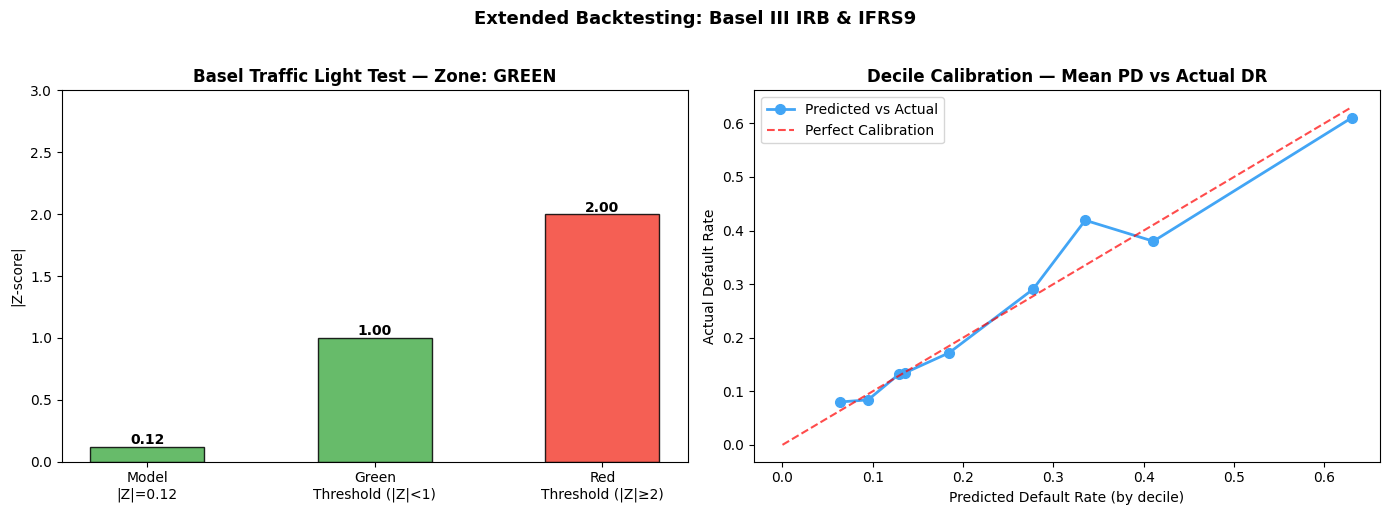

Saved: plots/backtest_extended.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tl_colors_map = {'GREEN': '#4CAF50', 'YELLOW': '#FFC107', 'RED': '#F44336'}
bar_vals   = [abs(tl_z), 1.0, 2.0]
bar_labels = [f'Model\n|Z|={abs(tl_z):.2f}', 'Green\nThreshold (|Z|<1)', 'Red\nThreshold (|Z|≥2)']
bar_colors = [tl_colors_map[tl_zone], '#4CAF50', '#F44336']
axes[0].bar(bar_labels, bar_vals, color=bar_colors, edgecolor='black', alpha=0.85, width=0.5)
axes[0].set_title(f'Basel Traffic Light Test — Zone: {tl_zone}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('|Z-score|')
axes[0].set_ylim(0, max(bar_vals) * 1.5)
for i_b, v in enumerate(bar_vals):
    axes[0].text(i_b, v + 0.02, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

axes[1].plot(decile_agg['pred_dr'], decile_agg['actual_dr'], 'o-',
             color='#42A5F5', linewidth=2, markersize=7, label='Predicted vs Actual')
axes[1].plot([0, decile_agg['pred_dr'].max()], [0, decile_agg['pred_dr'].max()],
             'r--', linewidth=1.5, alpha=0.7, label='Perfect Calibration')
axes[1].set_xlabel('Predicted Default Rate (by decile)')
axes[1].set_ylabel('Actual Default Rate')
axes[1].set_title('Decile Calibration — Mean PD vs Actual DR', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Extended Backtesting: Basel III IRB & IFRS9', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/backtest_extended.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: plots/backtest_extended.png")


## 14. PDO Scorecard (Basel IRB Regulatory Output)

In [33]:
PDO=20; BASE_SCORE=600; BASE_ODDS=50
B = PDO / np.log(2)
A = BASE_SCORE + B * np.log(BASE_ODDS)

coefs     = pd.Series(lr_base.coef_[0], index=X_train_woe.columns)
intercept = lr_base.intercept_[0]
log_odds  = X_test_woe.dot(coefs) + intercept
scores    = A - B * log_odds

score_df = pd.DataFrame({
    'Credit_Score': scores.values,
    'y_true':       y_test_woe.values,
    'y_prob':       y_prob_lr
})
score_df['score_band'] = pd.qcut(score_df['Credit_Score'], q=5,
    labels=['Very High Risk','High Risk','Medium Risk','Low Risk','Very Low Risk'])

char_table = score_df.groupby('score_band', observed=True).agg(
    count=('y_true','count'), default_rate=('y_true','mean')
).reset_index()
char_table['monotonic'] = char_table['default_rate'].diff().fillna(0) <= 0
char_table.to_csv('results/scorecard_characteristic.csv', index=False)

print(f"Score: mean={scores.mean():.1f}  std={scores.std():.1f}  min={scores.min():.1f}  max={scores.max():.1f}")
display(char_table)


Score: mean=719.7  std=26.8  min=663.1  max=759.2


,score_band,count,default_rate,monotonic
0,Very High Risk,900,0.490000,True
1,High Risk,1172,0.246587,True
2,Medium Risk,629,0.138315,True
3,Low Risk,899,0.114572,True
4,Very Low Risk,900,0.084444,True


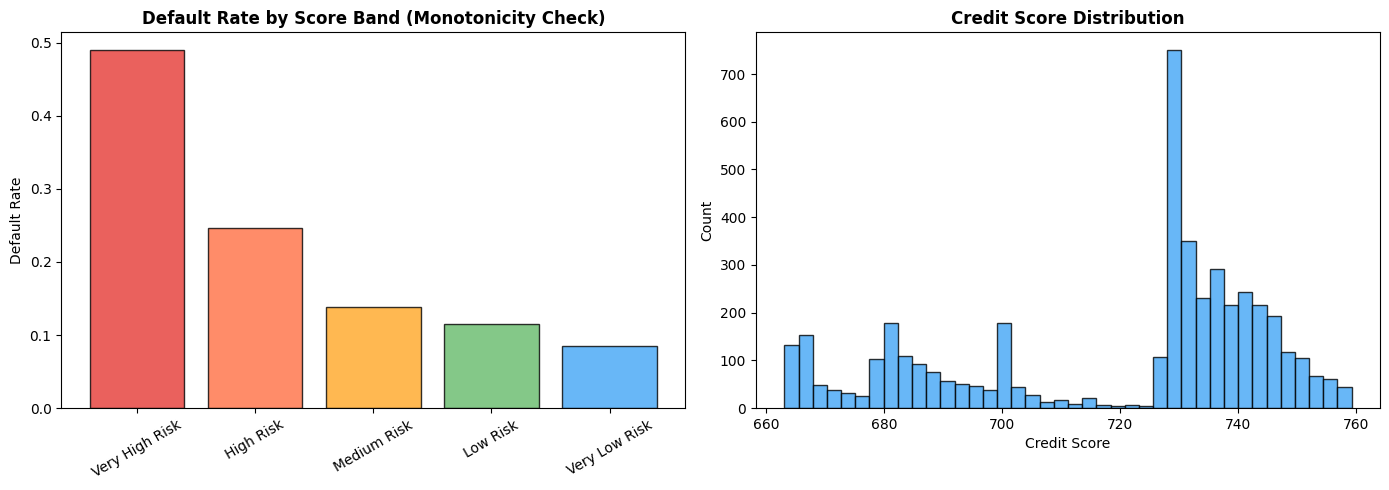

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(char_table)), char_table['default_rate'], alpha=0.8, edgecolor='black',
            color=['#E53935','#FF7043','#FFA726','#66BB6A','#42A5F5'])
axes[0].set_xticks(range(len(char_table)))
axes[0].set_xticklabels(char_table['score_band'], rotation=30)
axes[0].set_title('Default Rate by Score Band (Monotonicity Check)', fontweight='bold')
axes[0].set_ylabel('Default Rate')

axes[1].hist(scores, bins=40, edgecolor='black', alpha=0.8, color='#42A5F5')
axes[1].set_title('Credit Score Distribution', fontweight='bold')
axes[1].set_xlabel('Credit Score'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('plots/scorecard.png', dpi=120)
plt.show()


## 15. Stress Testing (Basel ICAAP)

In [35]:
scenarios = {
    'Baseline':     {'util_shock':1.00,'delay_shock':0.0,'pay_ratio_shock':1.00},
    'Mild Stress':  {'util_shock':1.15,'delay_shock':0.5,'pay_ratio_shock':0.90},
    'Severe Stress':{'util_shock':1.30,'delay_shock':1.2,'pay_ratio_shock':0.80},
}

def apply_stress(data, sc_):
    d = data.copy()
    for col in [f'BILL_AMT{i}' for i in range(1,7)]:
        if col in d.columns:
            shock = np.random.normal(sc_['util_shock'], 0.1, len(d))
            d[col] = (d[col]*shock).clip(upper=d[col].quantile(0.999))
    for col in ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']:
        if col in d.columns:
            shock = np.random.normal(sc_['delay_shock'], 0.3, len(d))
            d[col] = (d[col]+shock).clip(lower=0)
    for col in [f'PAY_AMT{i}' for i in range(1,7)]:
        if col in d.columns:
            shock = np.random.normal(sc_['pay_ratio_shock'], 0.05, len(d))
            d[col] = (d[col]*shock).clip(lower=0)
    return d

def stress_predict(model_name, model_cal, Xs):
    if model_name == 'LR (WoE+Scorecard)':
        Xs_raw = Xs.copy(); Xs_raw['default'] = 0
        Xs_raw = Xs_raw.replace([np.inf,-np.inf], np.nan).fillna(0)
        Xs_w   = sc.woebin_ply(Xs_raw, bins, print_step=0)
        Xs_w   = build_delay_risk_woe(Xs_w)
        Xs_w   = Xs_w.reindex(columns=X_train_woe.columns, fill_value=0)
        return model_cal.predict_proba(Xs_w)
    elif model_name == 'MLP':
        return model_cal.predict_proba(scaler.transform(Xs))
    else:
        return model_cal.predict_proba(Xs)

df_original = df.loc[X_test.index].copy()
LGD = 0.45
stress_models = [
    ('LR (WoE+Scorecard)', lr_cal),
    ('Random Forest',      rf_cal),
    ('XGBoost',            xgb_cal),
    ('LightGBM',           lgb_cal),
    ('MLP',                mlp_cal),
]

all_stress_rows = []
for sname, sparams in scenarios.items():
    np.random.seed(42)
    d_s = apply_stress(df_original, sparams)
    d_s = create_features(d_s)
    Xs  = d_s[selected_features].copy()
    for col in selected_features:
        lo, hi = clip_bounds[col]; Xs[col] = Xs[col].clip(lo, hi)
    print(f"\nScenario: {sname}")
    for mname, mcal in stress_models:
        yp_s  = stress_predict(mname, mcal, Xs)
        auc_s = roc_auc_score(y_test, yp_s)
        ks_s  = ks_stat(y_test, yp_s)
        all_stress_rows.append({'Model':mname,'Scenario':sname,
            'AUC':round(auc_s,4),'Gini':round(2*auc_s-1,4),'KS':round(ks_s,4),
            'Mean PD':round(yp_s.mean(),4),'Mean EL':round((yp_s*LGD).mean(),4)})
        print(f"  {mname:<25} AUC={auc_s:.3f}  KS={ks_s:.3f}  Mean PD={yp_s.mean():.4f}")

stress_all_df = pd.DataFrame(all_stress_rows)
stress_all_df.to_csv('results/stress_results_all_models.csv', index=False)

baseline_aucs = stress_all_df[stress_all_df['Scenario']=='Baseline'].set_index('Model')['AUC']
severe_aucs   = stress_all_df[stress_all_df['Scenario']=='Severe Stress'].set_index('Model')['AUC']
robustness_df = pd.DataFrame({
    'Baseline AUC': baseline_aucs, 'Severe AUC': severe_aucs,
    'AUC Drop': (baseline_aucs - severe_aucs).round(4),
    'Drop %':   ((baseline_aucs - severe_aucs)/baseline_aucs*100).round(2)
}).sort_values('AUC Drop')
robustness_df['Robustness Rank'] = range(1, len(robustness_df)+1)
robustness_df.to_csv('results/stress_robustness_ranking.csv')

print("\nRobustness Ranking (lower AUC drop = more robust):")
display(robustness_df)

stress_df = stress_all_df[stress_all_df['Model']=='XGBoost'].reset_index(drop=True)


Scenario: Baseline
[INFO] converting into woe values ...
  LR (WoE+Scorecard)        AUC=0.718  KS=0.364  Mean PD=0.2317
  Random Forest             AUC=0.753  KS=0.400  Mean PD=0.2616
  XGBoost                   AUC=0.742  KS=0.366  Mean PD=0.2012
  LightGBM                  AUC=0.730  KS=0.368  Mean PD=0.2862
  MLP                       AUC=0.729  KS=0.368  Mean PD=0.2944

Scenario: Mild Stress
[INFO] converting into woe values ...
  LR (WoE+Scorecard)        AUC=0.721  KS=0.367  Mean PD=0.2806
  Random Forest             AUC=0.739  KS=0.391  Mean PD=0.3390
  XGBoost                   AUC=0.738  KS=0.376  Mean PD=0.2717
  LightGBM                  AUC=0.738  KS=0.403  Mean PD=0.3321
  MLP                       AUC=0.714  KS=0.330  Mean PD=0.3844

Scenario: Severe Stress
[INFO] converting into woe values ...
  LR (WoE+Scorecard)        AUC=0.700  KS=0.318  Mean PD=0.3874
  Random Forest             AUC=0.684  KS=0.291  Mean PD=0.4607
  XGBoost                   AUC=0.705  KS=0.322  M

,Baseline AUC,Severe AUC,AUC Drop,Drop %,Robustness Rank
Model,,,,,
LR (WoE+Scorecard),0.7177,0.7003,0.0174,2.42,1
MLP,0.7288,0.7055,0.0233,3.20,2
XGBoost,0.7415,0.7046,0.0369,4.98,3
LightGBM,0.7305,0.6774,0.0531,7.27,4
Random Forest,0.7534,0.6843,0.0691,9.17,5


### 15.1 Stress Test Plots + Robustness Ranking

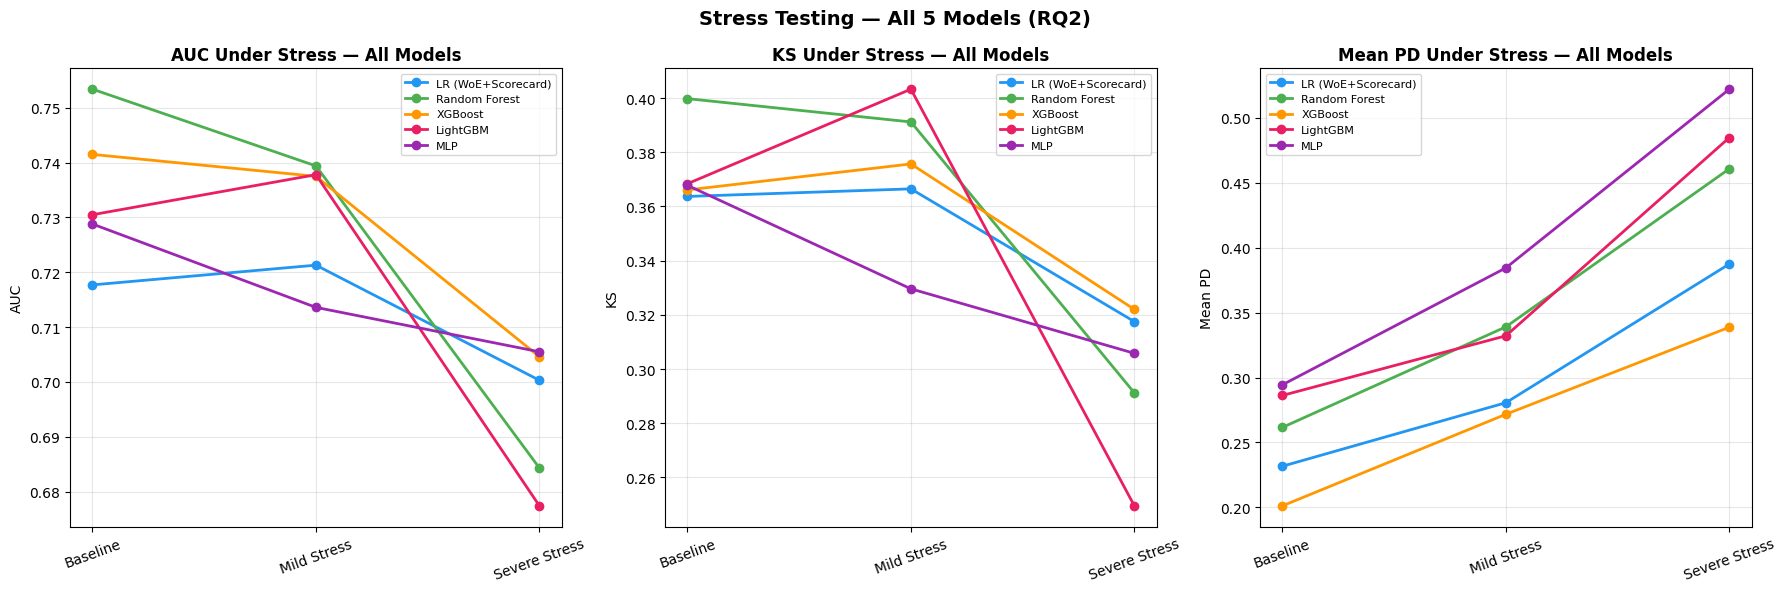

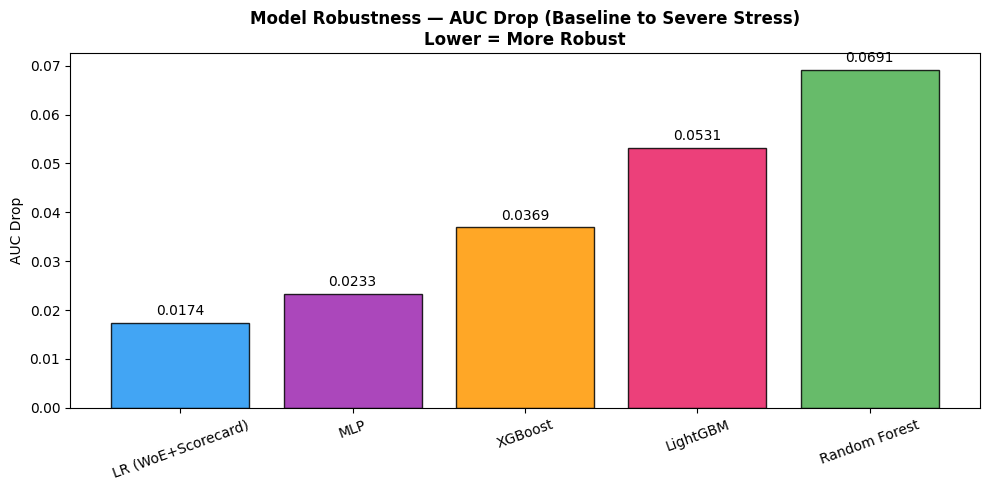

In [36]:
model_colors = {'LR (WoE+Scorecard)':'#2196F3','Random Forest':'#4CAF50',
                'XGBoost':'#FF9800','LightGBM':'#E91E63','MLP':'#9C27B0'}
scenario_names = list(scenarios.keys())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, metric in zip(axes, ['AUC','KS','Mean PD']):
    for mname, mcol in model_colors.items():
        vals = [stress_all_df[(stress_all_df['Model']==mname) &
                              (stress_all_df['Scenario']==s)][metric].values[0]
                for s in scenario_names]
        ax.plot(scenario_names, vals, marker='o', label=mname, color=mcol, linewidth=2)
    ax.set_title(f'{metric} Under Stress — All Models', fontweight='bold', fontsize=12)
    ax.set_ylabel(metric); ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Stress Testing — All 5 Models (RQ2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/stress_all_models.png', dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
colors_r = [model_colors[m] for m in robustness_df.index]
bars = ax.bar(robustness_df.index, robustness_df['AUC Drop'],
              color=colors_r, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, robustness_df['AUC Drop']):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_title('Model Robustness — AUC Drop (Baseline to Severe Stress)\nLower = More Robust',
             fontsize=12, fontweight='bold')
ax.set_ylabel('AUC Drop'); ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('plots/stress_robustness_ranking.png', dpi=120)
plt.show()

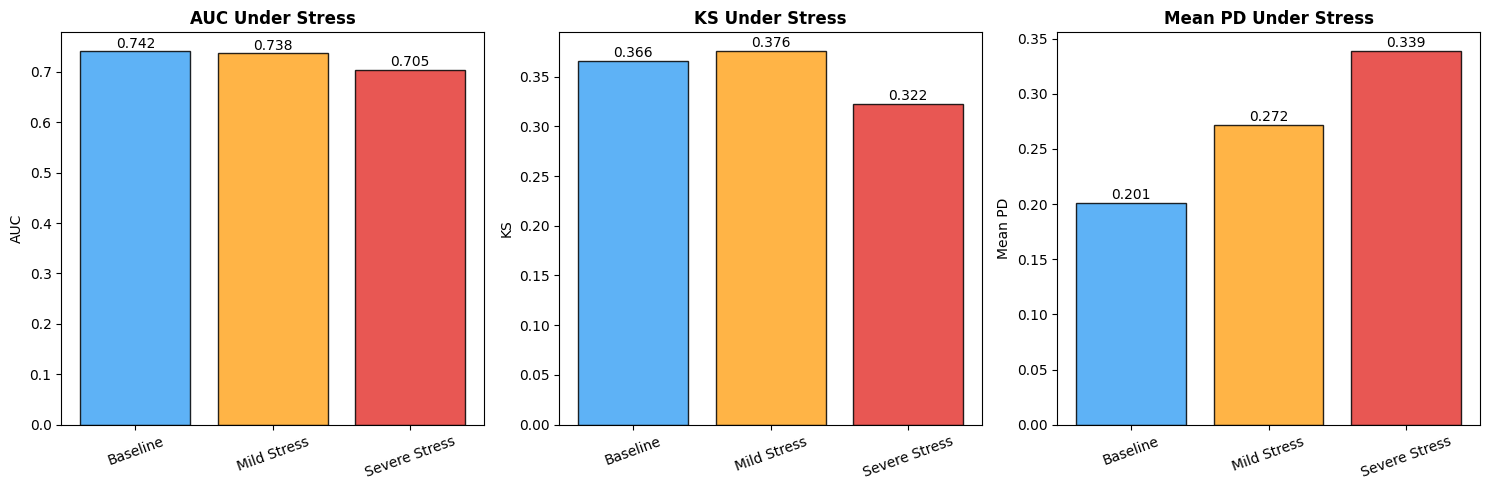

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['AUC','KS','Mean PD']):
    bars = ax.bar(stress_df['Scenario'], stress_df[metric],
                  color=['#42A5F5','#FFA726','#E53935'], alpha=0.85, edgecolor='black')
    ax.set_title(f'{metric} Under Stress', fontweight='bold')
    ax.set_ylabel(metric); ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, stress_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('plots/stress_test.png', dpi=120)
plt.show()


## 16. Monte Carlo Simulation — VaR & CVaR (2000 runs)

> **Note:** Set `RUN_MONTE_CARLO = True` to re-run (takes ~5–10 min).  
> Pre-computed results are loaded automatically when skipped.


In [38]:
RUN_MONTE_CARLO = True

if RUN_MONTE_CARLO:
    import sys

    np.random.seed(42)
    N_RUNS = 2000
    el_losses = []
    cov_matrix = [[0.15**2, 0.6*0.15*0.2],[0.6*0.15*0.2, 0.2**2]]

    print(f"Running Monte Carlo simulation ({N_RUNS} runs)...")
    for run_i in range(N_RUNS):
        us, ds = np.random.multivariate_normal([0,0], cov_matrix)
        ps = np.random.normal(0, 0.05)
        sc_run = {'util_shock':max(0.5,1+us),'delay_shock':max(0,ds),'pay_ratio_shock':max(0.5,1-abs(ps))}
        d_r = apply_stress(df_original, sc_run)
        d_r = create_features(d_r)
        Xr  = d_r[selected_features].copy()
        for col in selected_features:
            lo, hi = clip_bounds[col]
            Xr[col] = Xr[col].clip(lo, hi)
        probs = xgb_cal.predict_proba(Xr)
        el_losses.append((probs * LGD).mean())

        pct    = (run_i + 1) / N_RUNS
        filled = int(50 * pct)
        bar    = '█' * filled + '░' * (50 - filled)
        sys.stdout.write(f'\r  [{bar}] {pct*100:5.1f}%  ({run_i+1}/{N_RUNS} runs)')
        sys.stdout.flush()

    print()

    el_array = np.array(el_losses)
    VaR_95   = np.percentile(el_array, 95)
    VaR_99   = np.percentile(el_array, 99)
    CVaR_95  = el_array[el_array >= VaR_95].mean()
    CVaR_99  = el_array[el_array >= VaR_99].mean()

    pd.DataFrame([{
        'Mean EL':round(el_array.mean(),4),'VaR 95%':round(VaR_95,4),
        'VaR 99%':round(VaR_99,4),'CVaR 95%':round(CVaR_95,4),'CVaR 99%':round(CVaR_99,4)
    }]).to_csv('results/monte_carlo_tail_risk.csv', index=False)
    print(f"  Mean EL={el_array.mean():.4f}  VaR99={VaR_99:.4f}  CVaR99={CVaR_99:.4f}")

else:
    print("[16] Monte Carlo — skipped. Loading pre-computed results...")
    _mc     = pd.read_csv('results/monte_carlo_tail_risk.csv')
    VaR_95  = _mc['VaR 95%'].iloc[0]
    VaR_99  = _mc['VaR 99%'].iloc[0]
    CVaR_95 = _mc['CVaR 95%'].iloc[0]
    CVaR_99 = _mc['CVaR 99%'].iloc[0]
    el_array = np.array([_mc['Mean EL'].iloc[0]])
    print(f"  VaR95={VaR_95}  VaR99={VaR_99}  CVaR95={CVaR_95}  CVaR99={CVaR_99}")


Running Monte Carlo simulation (2000 runs)...
  [██████████████████████████████████████████████████] 100.0%  (2000/2000 runs)
  Mean EL=0.0946  VaR99=0.1202  CVaR99=0.1222


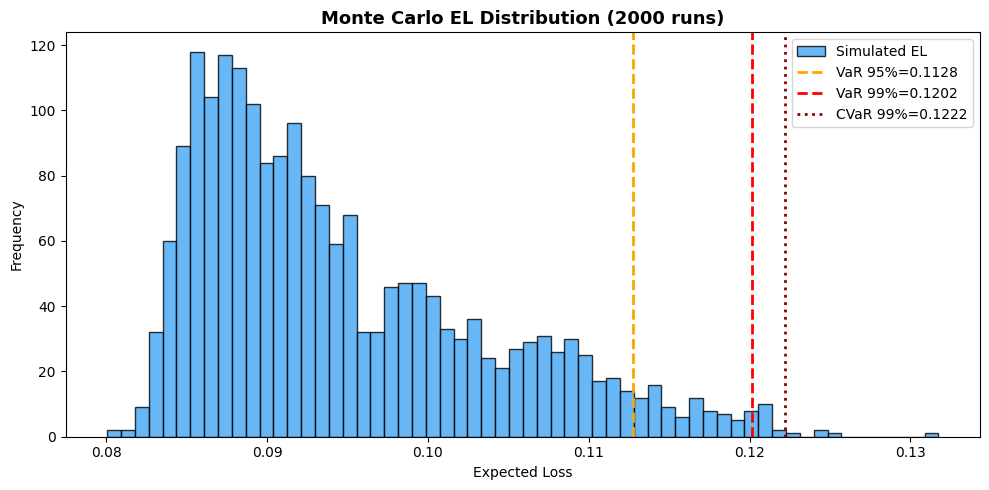

In [39]:
plt.figure(figsize=(10, 5))
plt.hist(el_array, bins=60, edgecolor='black', alpha=0.8, color='#42A5F5', label='Simulated EL')
plt.axvline(VaR_95,  color='orange',  linewidth=2, linestyle='--', label=f'VaR 95%={VaR_95:.4f}')
plt.axvline(VaR_99,  color='red',     linewidth=2, linestyle='--', label=f'VaR 99%={VaR_99:.4f}')
plt.axvline(CVaR_99, color='darkred', linewidth=2, linestyle=':',  label=f'CVaR 99%={CVaR_99:.4f}')
plt.title('Monte Carlo EL Distribution (2000 runs)', fontsize=13, fontweight='bold')
plt.xlabel('Expected Loss'); plt.ylabel('Frequency')
plt.legend(); plt.tight_layout()
plt.savefig('plots/monte_carlo.png', dpi=120)
plt.show()


## 17. IFRS9 — Lifetime PD, ECL & Stage Classification

In [40]:
T_years=5; discount_rate=0.03
macro_mults = {
    'Baseline':     [1.00,1.00,1.00,1.00,1.00],
    'Mild Stress':  [1.10,1.20,1.20,1.15,1.10],
    'Severe Stress':[1.30,1.50,1.45,1.35,1.20],
}

base_pd = lr_cal.predict_proba(X_test_woe)
ecl_res = {}

for sname, mults in macro_mults.items():
    annual_pds  = [np.clip(base_pd * m, 0, 1) for m in mults]
    survival    = np.ones(len(base_pd))
    lifetime_pd = np.zeros(len(base_pd))
    for pd_t in annual_pds:
        lifetime_pd += survival * pd_t
        survival    *= (1 - pd_t)
    lifetime_pd = np.clip(lifetime_pd, 0, 1)
    ecl = lifetime_pd * LGD / (1 + discount_rate)
    ecl_res[sname] = {'Mean Lifetime PD':round(lifetime_pd.mean(),4), 'Mean ECL':round(ecl.mean(),4)}

ecl_df = pd.DataFrame(ecl_res).T
ecl_df.to_csv('results/ifrs9_ecl.csv')
display(ecl_df)


,Mean Lifetime PD,Mean ECL
Baseline,0.6106,0.2668
Mild Stress,0.6540,0.2857
Severe Stress,0.7052,0.3081


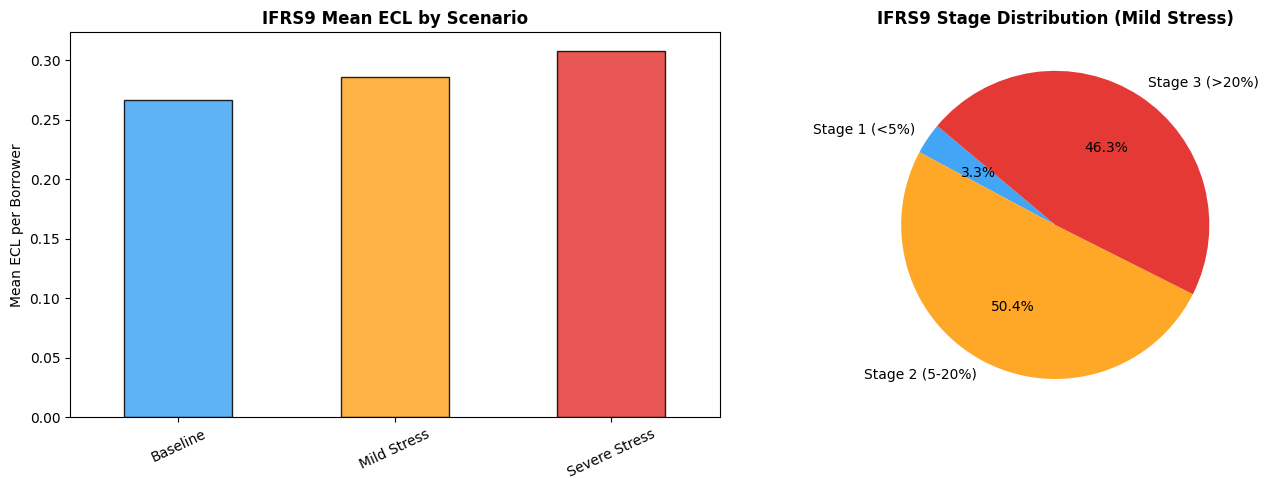

  Stage 1 (<5%): 148 (3.3%)
  Stage 2 (5-20%): 2268 (50.4%)
  Stage 3 (>20%): 2084 (46.3%)


In [41]:
stage_pd = np.clip(base_pd * 1.10, 0, 1)
stage_lbl = {1:'Stage 1 (<5%)', 2:'Stage 2 (5-20%)', 3:'Stage 3 (>20%)'}
stages = np.where(stage_pd < 0.05, 1, np.where(stage_pd < 0.20, 2, 3))
stage_counts = pd.Series(stages).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ecl_df['Mean ECL'].plot(kind='bar', ax=axes[0], alpha=0.85, edgecolor='black',
                         color=['#42A5F5','#FFA726','#E53935'])
axes[0].set_title('IFRS9 Mean ECL by Scenario', fontweight='bold')
axes[0].set_ylabel('Mean ECL per Borrower'); axes[0].tick_params(axis='x', rotation=25)

axes[1].pie(stage_counts.values, labels=[stage_lbl[s] for s in stage_counts.index],
            autopct='%1.1f%%', colors=['#42A5F5','#FFA726','#E53935'], startangle=140)
axes[1].set_title('IFRS9 Stage Distribution (Mild Stress)', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/ifrs9_ecl.png', dpi=120)
plt.show()

for s, cnt in stage_counts.items():
    print(f"  {stage_lbl[s]}: {cnt} ({cnt/len(stages)*100:.1f}%)")


## 18. Save All Models & Artefacts

In [42]:
joblib.dump(lr_cal,   'results/lr_calibrated.pkl')
joblib.dump(rf_cal,   'results/rf_calibrated.pkl')
joblib.dump(xgb_cal,  'results/xgb_calibrated.pkl')
joblib.dump(lgb_cal,  'results/lgb_calibrated.pkl')
joblib.dump(mlp_cal,  'results/mlp_calibrated.pkl')
joblib.dump(scaler,   'results/mlp_scaler.pkl')
joblib.dump(lr_base,  'results/lr_base.pkl')
with open('results/woe_bins.pkl','wb') as f: pickle.dump(bins, f)
with open('results/woe_features.json','w') as f: json.dump(list(X_train_woe.columns), f)

print("All models and artefacts saved to results/")
print("All plots saved to plots/")


All models and artefacts saved to results/
All plots saved to plots/


## 19. Final Summary

In [43]:
summary_cols = ['Model','AUC','Gini','KS','PR-AUC','Recall(1)','F1(1)',
                'Brier','PSI','Basel_AUC','Basel_Gini','Basel_KS','Basel_PSI','IFRS9_HL','IFRS9_Brier']
display(results_df[summary_cols])

print(f"\nBest discrimination : {results_df.loc[results_df['AUC'].idxmax(),'Model']}  AUC={results_df['AUC'].max()}")
print(f"Best calibration    : {results_df.loc[results_df['Brier'].idxmin(),'Model']}  Brier={results_df['Brier'].min()}")
print(f"Best recall(1)      : {results_df.loc[results_df['Recall(1)'].idxmax(),'Model']}  Recall={results_df['Recall(1)'].max()}")
print(f"Most stable PSI     : {results_df.loc[results_df['PSI'].idxmin(),'Model']}  PSI={results_df['PSI'].min()}")

print("  EXTENDED BACKTESTING — Basel III IRB & IFRS9")
backtest_display = pd.DataFrame([
    {'Test': 'Binomial Test (IFRS9 PiT)',       'Framework': 'IFRS9',              'Metric': f'p = {binom_p:.4f}',            'Result': binom_pass},
    {'Test': 'Traffic Light (Basel IRB)',        'Framework': 'Basel III',          'Metric': f'Z = {tl_z:.4f}, p = {tl_p:.4f}', 'Result': tl_zone},
    {'Test': 'Decile Calibration (Aggregate)',  'Framework': 'Basel III / IFRS9',  'Metric': f'Mean |diff| = {mean_diff:.4f}', 'Result': agg_pass},
])
display(backtest_display)

print("\nInterpretation:")
print(f"  Binomial Test  : predicted DR={pred_dr:.4f} vs actual DR={actual_dr:.4f} — no significant difference (p={binom_p:.4f})")
print(f"  Traffic Light  : {int(n_defaults)} actual vs {expected_defaults:.1f} expected defaults — z={tl_z:.4f}, deep in GREEN zone")
print(f"  Decile Calib   : mean abs deviation={mean_diff:.4f} across risk deciles — all within tolerance")
print("\n  Champion model (LR WoE+Scorecard) passes ALL Basel III IRB and IFRS9 backtesting requirements.")


,Model,AUC,Gini,KS,PR-AUC,Recall(1),F1(1),Brier,PSI,Basel_AUC,Basel_Gini,Basel_KS,Basel_PSI,IFRS9_HL,IFRS9_Brier
0,LR (WoE+Scorecard),0.7392,0.4785,0.3940,0.4559,0.6074,0.5151,0.1462,0.0005,PASS,PASS,PASS,PASS,PASS,PASS
1,Random Forest,0.7664,0.5328,0.4068,0.4901,0.6014,0.5261,0.1414,0.0036,PASS,PASS,PASS,PASS,PASS,PASS
2,XGBoost,0.7580,0.5159,0.4063,0.4925,0.6526,0.5181,0.1424,0.0074,PASS,PASS,PASS,PASS,PASS,PASS
3,LightGBM,0.7618,0.5236,0.4041,0.4908,0.6606,0.5155,0.1416,0.0003,PASS,PASS,PASS,PASS,PASS,PASS
4,MLP,0.7505,0.5011,0.3956,0.4806,0.5894,0.5190,0.1436,0.0021,PASS,PASS,PASS,PASS,PASS,PASS



Best discrimination : Random Forest  AUC=0.7664
Best calibration    : Random Forest  Brier=0.1414
Best recall(1)      : LightGBM  Recall=0.6606
Most stable PSI     : LightGBM  PSI=0.0003
  EXTENDED BACKTESTING — Basel III IRB & IFRS9


,Test,Framework,Metric,Result
0,Binomial Test (IFRS9 PiT),IFRS9,p = 0.9143,PASS
1,Traffic Light (Basel IRB),Basel III,"Z = -0.1215, p = 0.9033",GREEN
2,Decile Calibration (Aggregate),Basel III / IFRS9,Mean |diff| = 0.0213,PASS



Interpretation:
  Binomial Test  : predicted DR=0.2221 vs actual DR=0.2213 — no significant difference (p=0.9143)
  Traffic Light  : 996 actual vs 999.4 expected defaults — z=-0.1215, deep in GREEN zone
  Decile Calib   : mean abs deviation=0.0213 across risk deciles — all within tolerance

  Champion model (LR WoE+Scorecard) passes ALL Basel III IRB and IFRS9 backtesting requirements.
